# DDoS Attacks Detection and Characterization


In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import datetime 
import ipaddress

In [2]:
df = pd.read_csv('ddos_dataset.csv',low_memory=False)

# we create a copy of the original dataset
df_copy = df.copy()
df

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,label
0,0,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,2018-12-01 10:51:39.813448,28415,97,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_dns
1,1,172.16.0.5-192.168.50.1-60495-634-17,192.168.50.1,634,172.16.0.5,60495,17,2018-12-01 10:51:39.820842,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,ddos_dns
2,2,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,2018-12-01 10:51:39.852499,48549,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_dns
3,3,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,2018-12-01 10:51:39.890213,48337,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_dns
4,4,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,2018-12-01 10:51:39.941151,32026,200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_dns
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,65995,172.16.0.5-192.168.50.1-38625-63051-17,172.16.0.5,38625,192.168.50.1,63051,17,2018-12-01 13:04:46.628249,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_udp_lag
64235,65996,172.16.0.5-192.168.50.1-58632-18963-17,172.16.0.5,58632,192.168.50.1,18963,17,2018-12-01 13:04:46.628963,212238,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_udp_lag
64236,65997,172.16.0.5-192.168.50.1-46104-64704-17,172.16.0.5,46104,192.168.50.1,64704,17,2018-12-01 13:04:46.629014,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_udp_lag
64237,65998,172.16.0.5-192.168.50.1-60686-10440-17,172.16.0.5,60686,192.168.50.1,10440,17,2018-12-01 13:04:46.629016,108952,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,ddos_udp_lag


# Section 1 – Data exploration and pre-processing

## 1. Investigate the provided DDoS attack dataset

I dati sono stati raccolti il giorno 1 dicembre 2018 dalle 09:17:11 alle 13:34:27. TODO: Da tradurre

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64239 entries, 0 to 64238
Data columns (total 88 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    64239 non-null  int64  
 1   Flow ID                       64239 non-null  object 
 2    Source IP                    64239 non-null  object 
 3    Source Port                  64239 non-null  int64  
 4    Destination IP               64239 non-null  object 
 5    Destination Port             64239 non-null  int64  
 6    Protocol                     64239 non-null  int64  
 7    Timestamp                    64239 non-null  object 
 8    Flow Duration                64239 non-null  int64  
 9    Total Fwd Packets            64239 non-null  int64  
 10   Total Backward Packets       64239 non-null  int64  
 11  Total Length of Fwd Packets   64239 non-null  float64
 12   Total Length of Bwd Packets  64239 non-null  float64
 13   

In [4]:
# we fix column names
df.columns = [col.strip().replace(" ", "") for col in df.columns] 

# we drop the first column which is unnecessary
df.drop(columns=['Unnamed:0'],inplace=True)

# we put 1 when the value of SimilarHTTP is different from zero
df['SimillarHTTP'] = df['SimillarHTTP'].apply(lambda x : 1 if x != 0 else 0)
print(df['SimillarHTTP'].value_counts())
df.head()

SimillarHTTP
1    64239
Name: count, dtype: int64


,FlowID,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FlowDuration,TotalFwdPackets,TotalBackwardPackets,...,ActiveStd,ActiveMax,ActiveMin,IdleMean,IdleStd,IdleMax,IdleMin,SimillarHTTP,Inbound,label
0,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,2018-12-01 10:51:39.813448,28415,97,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,ddos_dns
1,172.16.0.5-192.168.50.1-60495-634-17,192.168.50.1,634,172.16.0.5,60495,17,2018-12-01 10:51:39.820842,2,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,ddos_dns
2,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,2018-12-01 10:51:39.852499,48549,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,ddos_dns
3,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,2018-12-01 10:51:39.890213,48337,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,ddos_dns
4,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,2018-12-01 10:51:39.941151,32026,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,ddos_dns


We now remove columns that have the same value in every row.

In [5]:
unique_val = df.apply(lambda col: col.unique())

col_unique_val = unique_val[unique_val.apply(len) == 1].index

print("Columns meaningless beacuse they have the same value on all rows:")
print(col_unique_val)

df.drop(columns=col_unique_val,inplace=True)

print(f"The dataset has now {df.shape[0]} rows and {df.shape[1]}")

Columns meaningless beacuse they have the same value on all rows:
Index(['BwdPSHFlags', 'FwdURGFlags', 'BwdURGFlags', 'FINFlagCount',
       'PSHFlagCount', 'ECEFlagCount', 'FwdAvgBytes/Bulk',
       'FwdAvgPackets/Bulk', 'FwdAvgBulkRate', 'BwdAvgBytes/Bulk',
       'BwdAvgPackets/Bulk', 'BwdAvgBulkRate', 'SimillarHTTP'],
      dtype='object')
The dataset has now 64239 rows and 74


In [6]:
df.describe()

,SourcePort,DestinationPort,Protocol,FlowDuration,TotalFwdPackets,TotalBackwardPackets,TotalLengthofFwdPackets,TotalLengthofBwdPackets,FwdPacketLengthMax,FwdPacketLengthMin,...,min_seg_size_forward,ActiveMean,ActiveStd,ActiveMax,ActiveMin,IdleMean,IdleStd,IdleMax,IdleMin,Inbound
count,64239.000000,64239.000000,64239.000000,6.423900e+04,64239.000000,64239.000000,64239.000000,6.423900e+04,64239.000000,64239.000000,...,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,6.423900e+04,64239.000000
mean,25267.368608,30715.252884,14.362864,5.150614e+06,18.814848,1.304036,6699.521630,2.153348e+03,613.992948,588.863043,...,-4.167229e+07,9.026629e+03,4.878774e+03,1.687791e+04,6.204895e+03,1.155553e+06,2.613584e+05,1.555321e+06,8.908522e+05,0.919566
std,24710.413442,20347.990914,4.706001,2.249713e+07,462.305336,25.199720,20510.320389,9.087201e+04,585.691655,584.276284,...,2.062767e+08,2.045563e+05,1.424082e+05,3.828583e+05,1.667756e+05,5.341380e+06,1.574889e+06,6.993415e+06,4.571276e+06,0.271966
min,0.000000,0.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,-1.062719e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,779.000000,12435.500000,17.000000,1.000000e+00,2.000000,0.000000,123.000000,0.000000e+00,53.000000,36.000000,...,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
50%,29661.000000,30797.000000,17.000000,2.000000e+00,2.000000,0.000000,1050.000000,0.000000e+00,393.000000,375.000000,...,1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
75%,48510.500000,49041.500000,17.000000,2.087700e+04,2.000000,0.000000,2944.000000,0.000000e+00,1464.000000,1464.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,65518.000000,65535.000000,17.000000,1.200000e+08,85894.000000,1862.000000,176000.000000,8.829488e+06,3564.000000,2020.000000,...,1.480000e+03,1.678654e+07,2.853681e+07,6.783473e+07,8.349846e+06,1.147455e+08,5.275036e+07,1.147455e+08,1.147455e+08,1.000000


In [7]:
df['FlowID']=df["SourceIP"] + "-" + df["DestinationIP"] + "-" + \
               df["SourcePort"].astype(str) + "-" + \
               df["DestinationPort"].astype(str) + "-" + \
               df["Protocol"].astype(str)
df

,FlowID,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FlowDuration,TotalFwdPackets,TotalBackwardPackets,...,ActiveMean,ActiveStd,ActiveMax,ActiveMin,IdleMean,IdleStd,IdleMax,IdleMin,Inbound,label
0,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,2018-12-01 10:51:39.813448,28415,97,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_dns
1,192.168.50.1-172.16.0.5-634-60495-17,192.168.50.1,634,172.16.0.5,60495,17,2018-12-01 10:51:39.820842,2,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,ddos_dns
2,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,2018-12-01 10:51:39.852499,48549,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_dns
3,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,2018-12-01 10:51:39.890213,48337,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_dns
4,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,2018-12-01 10:51:39.941151,32026,200,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_dns
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,172.16.0.5-192.168.50.1-38625-63051-17,172.16.0.5,38625,192.168.50.1,63051,17,2018-12-01 13:04:46.628249,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_udp_lag
64235,172.16.0.5-192.168.50.1-58632-18963-17,172.16.0.5,58632,192.168.50.1,18963,17,2018-12-01 13:04:46.628963,212238,6,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_udp_lag
64236,172.16.0.5-192.168.50.1-46104-64704-17,172.16.0.5,46104,192.168.50.1,64704,17,2018-12-01 13:04:46.629014,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_udp_lag
64237,172.16.0.5-192.168.50.1-60686-10440-17,172.16.0.5,60686,192.168.50.1,10440,17,2018-12-01 13:04:46.629016,108952,4,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,ddos_udp_lag


### BASIC TRAFFIC STATISTICS

In [8]:
n_flow=df['FlowID'].nunique() # 64239
n_src_ip = df["SourceIP"].nunique()
n_dst_ip = df["DestinationIP"].nunique()

print(f"Number of unique source IPs: {n_src_ip}")
print(f"Number of unique destination IPs: {n_dst_ip}")
n_flow

Number of unique source IPs: 216
Number of unique destination IPs: 245


62154

### LABEL DISTRIBUTION

In [9]:
df_masked=df[df['label']=='benign']
num_benign=df_masked['label'].count() # 5658

num_attack=len(df)-num_benign # 58581
num_attackpertype=df[df['label']!='benign'].groupby(["label"]).size()   # int(num_attacktype[i])
num_attackpertype

label
ddos_dns        5369
ddos_ldap       5928
ddos_mssql      5911
ddos_netbios    5830
ddos_ntp         986
ddos_snmp       5984
ddos_ssdp       5970
ddos_syn        5480
ddos_tftp       5261
ddos_udp        5876
ddos_udp_lag    5986
dtype: int64

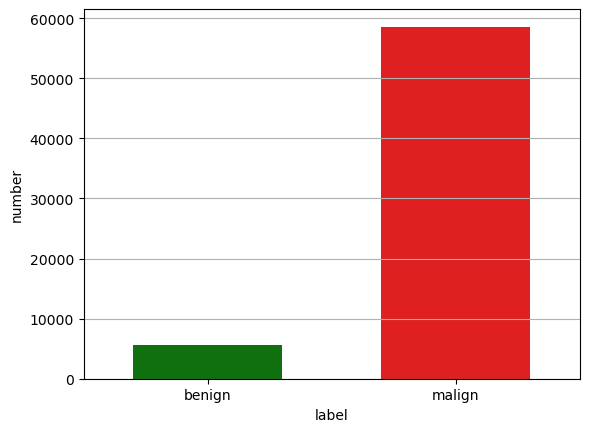

In [10]:
df_benign= pd.DataFrame({
    'label' : ['benign','malign'], 
    'number' : [num_benign, num_attack]
})

sns.barplot(
    data = df_benign, # which dataframe you want to use as the source data
    x = 'label', # which column to use for x-axis
    y = 'number', # which column to use for y-axis
    width=0.6,
    palette = ['green', 'red'],
    hue = 'label',
    legend = False
)
plt.grid(True)             
plt.grid(axis='x')
plt.show()

### TRAFIC LEVEL DISTRIBUITION

#### PROTOCOL

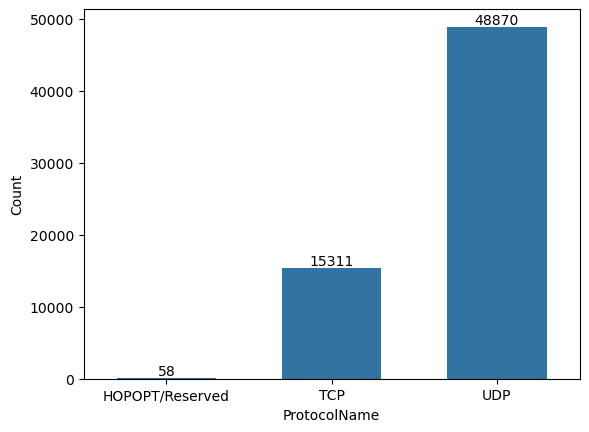

In [11]:
prt_map = {
    6: 'TCP',
    17: 'UDP',
    0: 'HOPOPT/Reserved'
}


df['ProtocolName'] = df['Protocol'].replace(prt_map)

df_prot=df.groupby('ProtocolName')['ProtocolName'].count()
df_prot=pd.DataFrame(df_prot)
df_prot.columns=['Count']

ax = sns.barplot(data = df_prot, x = df_prot.index, y = 'Count', width=0.6)

# Aggiungere i valori sopra le barre
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')
plt.show()

### IP SOURCE/DESTINATION 

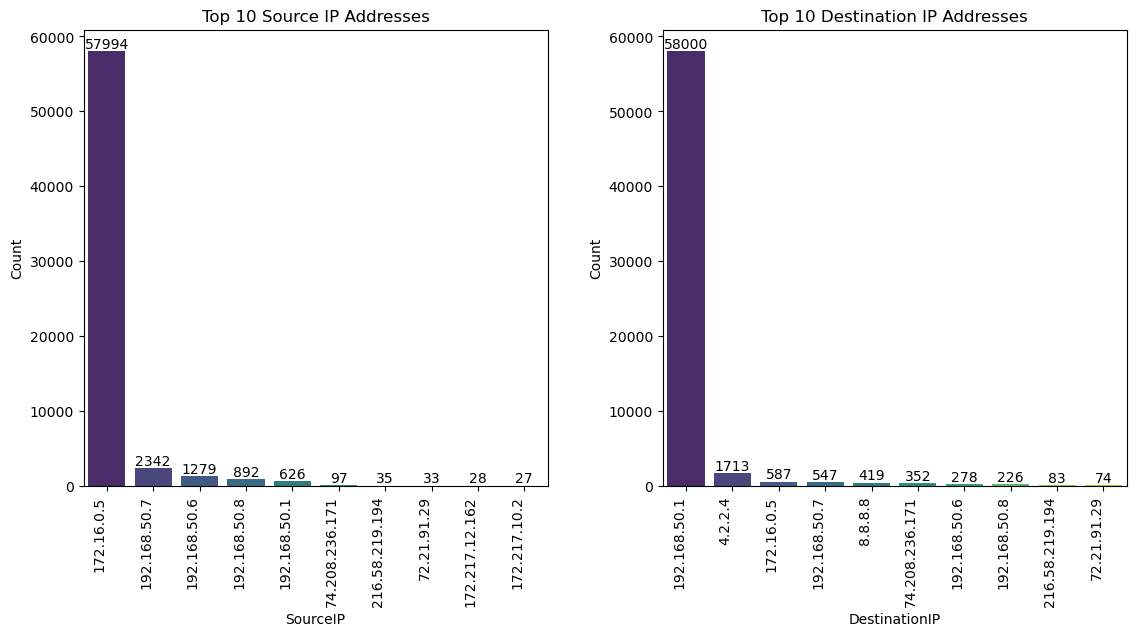

In [12]:
plt.figure(figsize=(12, 7))

plt.subplot(1,2,1)
IP_Source_dist = df['SourceIP'].value_counts().head(10)
IP_Source_dist = pd.DataFrame(IP_Source_dist)
IP_Source_dist.columns = ['Count']
ax = sns.barplot(
    data = IP_Source_dist,
    x = 'SourceIP',
    y = 'Count',
    palette='viridis',
    hue = 'SourceIP',
    legend = False
    
)
plt.title('Top 10 Source IP Addresses')
plt.xticks(rotation=90, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.subplot(1,2,2)
IP_Destination_dist = df['DestinationIP'].value_counts().head(10)
IP_Destination_dist = pd.DataFrame(IP_Destination_dist)
IP_Destination_dist.columns = ['Count']
ax = sns.barplot(
    data = IP_Destination_dist,
    x = 'DestinationIP',
    y = 'Count',
    palette='viridis',
    hue = 'DestinationIP',
    legend = False
    
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Destination IP Addresses')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

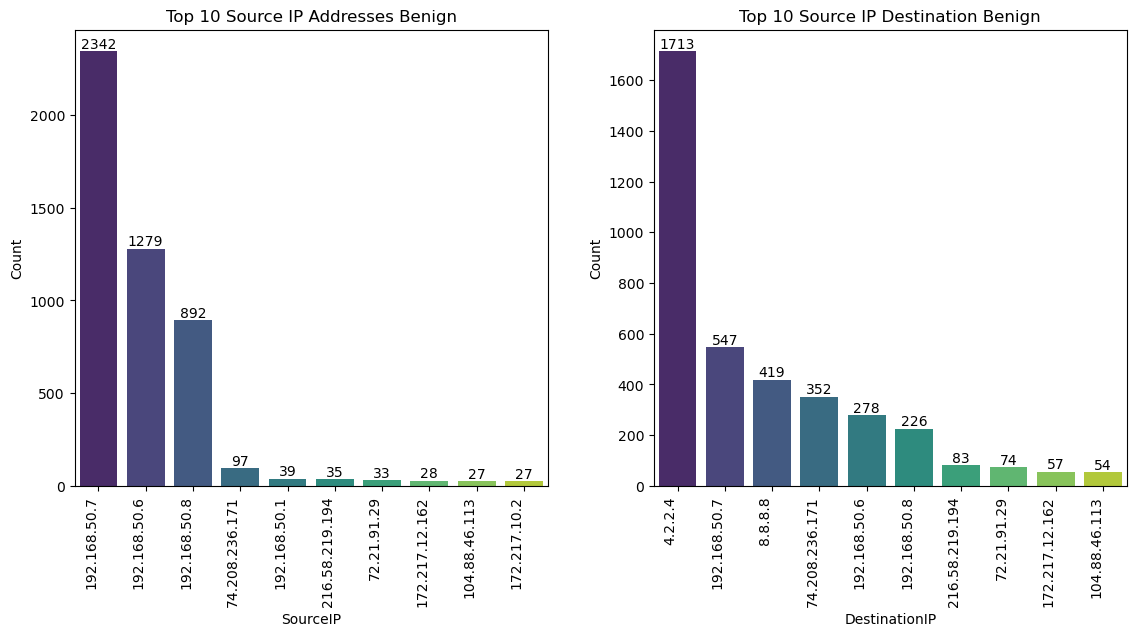

In [13]:
plt.figure(figsize=(12, 7))

plt.subplot(1,2,1)
IP_Source_dist_Benign = df['SourceIP'][df['label'] == 'benign'].value_counts().head(10)
IP_Source_dist_Benign = pd.DataFrame(IP_Source_dist_Benign)
IP_Source_dist_Benign.columns = ['Count']
ax = sns.barplot(
    data = IP_Source_dist_Benign,
    x = 'SourceIP',
    y = 'Count',
    palette='viridis',
    hue = 'SourceIP',
    legend = False
    
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source IP Addresses Benign')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.subplot(1,2,2)
IP_Source_dist_Benign = df['DestinationIP'][df['label'] == 'benign'].value_counts().head(10)
IP_Source_dist_Benign = pd.DataFrame(IP_Source_dist_Benign)
IP_Source_dist_Benign.columns = ['Count']
ax = sns.barplot(
    data = IP_Source_dist_Benign,
    x = 'DestinationIP',
    y = 'Count',
    palette='viridis',
    hue = 'DestinationIP',
    legend = False
    
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source IP Destination Benign')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

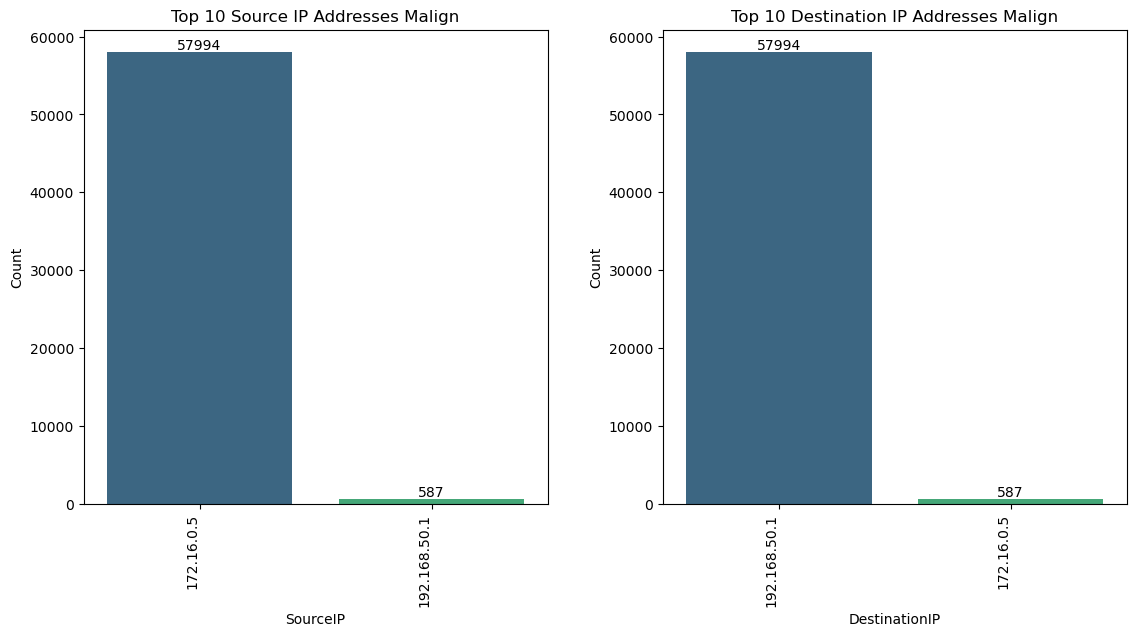

In [14]:
plt.figure(figsize=(12, 7))

plt.subplot(1,2,1)
IP_Source_dist_Malign = df['SourceIP'][df['label'] != 'benign'].value_counts().head(10)
IP_Source_dist_Malign = pd.DataFrame(IP_Source_dist_Malign)
IP_Source_dist_Malign.columns = ['Count']
ax = sns.barplot(
    data = IP_Source_dist_Malign,
    x = 'SourceIP',
    y = 'Count',
    palette='viridis',
    hue = 'SourceIP',
    legend = False
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source IP Addresses Malign')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.subplot(1,2,2)
IP_Destination_dist_Malign = df['DestinationIP'][df['label'] != 'benign'].value_counts().head(10)
IP_Destination_dist_Malign = pd.DataFrame(IP_Destination_dist_Malign)
IP_Destination_dist_Malign.columns = ['Count']
ax = sns.barplot(
    data = IP_Destination_dist_Malign,
    x = 'DestinationIP',
    y = 'Count',
    palette='viridis',
    hue = 'DestinationIP',
    legend = False
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Destination IP Addresses Malign')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')




plt.tight_layout(pad=3)

### TOP 10 DESTINATION/SOURCE PORTS 

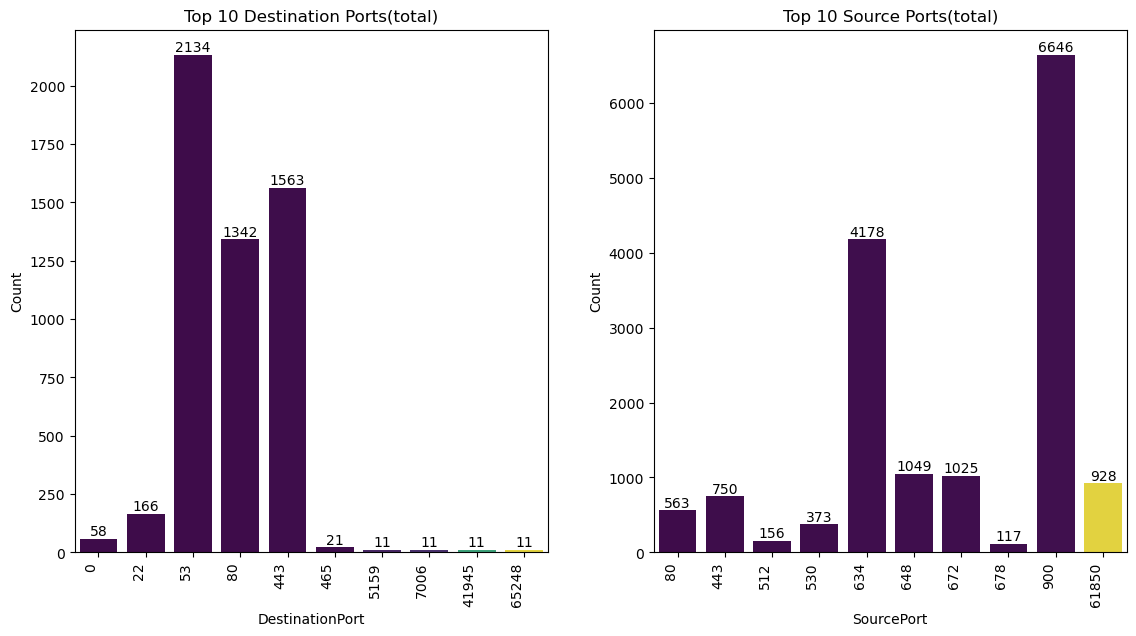

In [15]:
plt.figure(figsize=(12, 7))

plt.subplot(1,2,1)
Destination_Port_dist = df['DestinationPort'].value_counts().head(10)
Destination_Port_dist = pd.DataFrame(Destination_Port_dist)
Destination_Port_dist.columns = ['Count']
ax = sns.barplot(
    data = Destination_Port_dist,
    x = 'DestinationPort',
    y = 'Count',
    palette='viridis',
    hue = 'DestinationPort',
    legend = False
    
)
plt.title('Top 10 Destination Ports(total)')
plt.xticks(rotation=90, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')


# secondo subplot, quello a destra
plt.subplot(1,2,2)
Source_Port_dist= df['SourcePort'].value_counts().head(10)
Source_Port_dist = pd.DataFrame(Source_Port_dist)
Source_Port_dist.columns = ['Count']
ax = sns.barplot(
    data = Source_Port_dist,
    x = 'SourcePort',
    y = 'Count',
    palette='viridis',
    hue = 'SourcePort',
    legend = False
    
)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source Ports(total)')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

### TOP 10 DESTINATION / SOURCE PORTS (BENIGN)

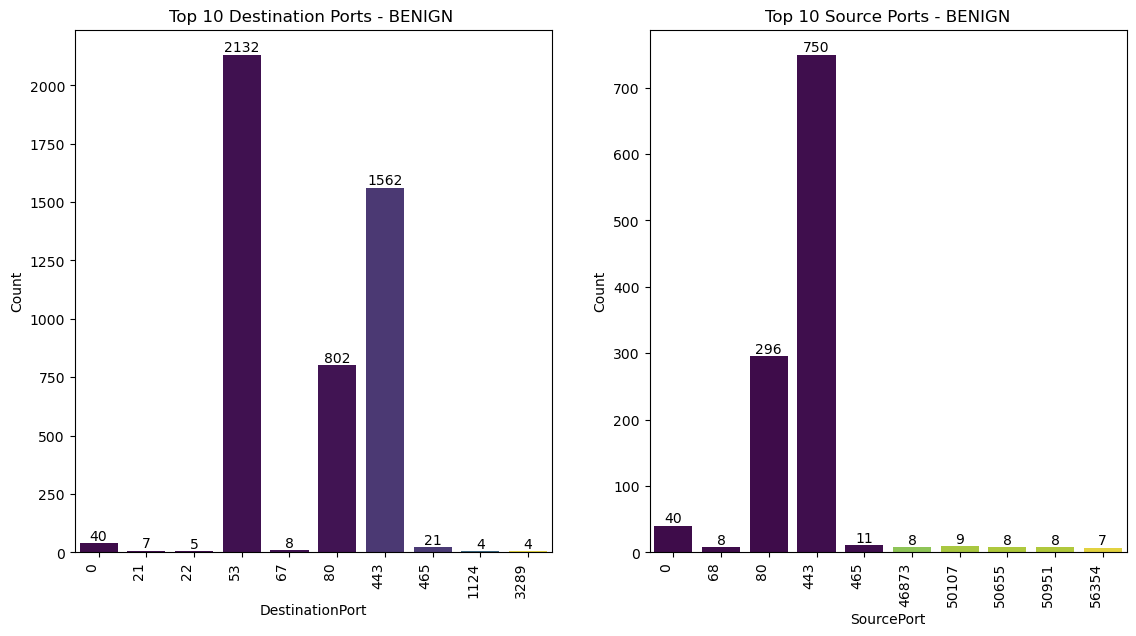

In [16]:
plt.figure(figsize=(12, 7))
plt.subplot(1,2,1)
Destination_Port_dist_Benign = df['DestinationPort'][df['label'] == 'benign'].value_counts().head(10)
Destination_Port_dist_Benign = pd.DataFrame(Destination_Port_dist_Benign)
Destination_Port_dist_Benign.columns = ['Count']
ax = sns.barplot(
data = Destination_Port_dist_Benign,
x = 'DestinationPort',
y = 'Count',
palette='viridis',
hue = 'DestinationPort',
legend = False

)
plt.title('Top 10 Destination Ports - BENIGN ')
plt.xticks(rotation=90, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# secondo subplot, quello a destra

plt.subplot(1,2,2)
Source_Port_dist_Benign= df['SourcePort'][df['label'] == 'benign'].value_counts().head(10)
Source_Port_dist_Benign = pd.DataFrame(Source_Port_dist_Benign)
Source_Port_dist_Benign.columns = ['Count']
ax = sns.barplot(
data = Source_Port_dist_Benign,
x = 'SourcePort',
y = 'Count',
palette='viridis',
hue = 'SourcePort',
legend = False

)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source Ports - BENIGN')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

### TOP 10 DESTINATION / SOURCE PORTS (MALIGN)

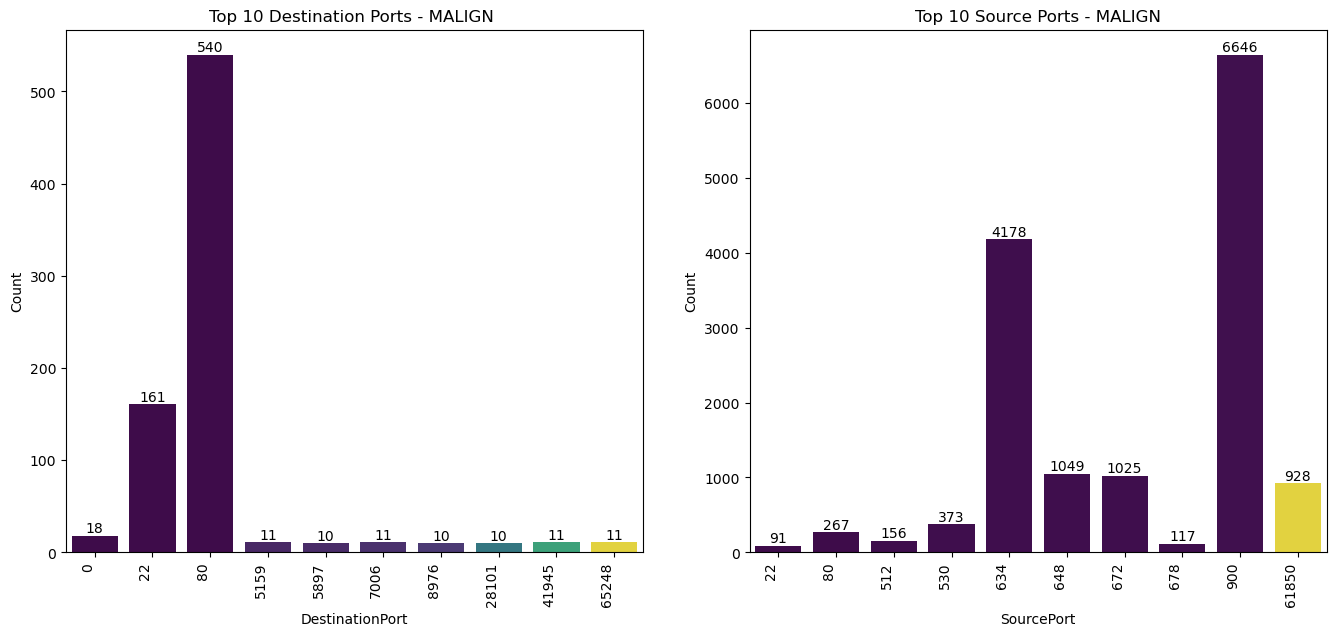

In [17]:
plt.figure(figsize=(14, 7))
plt.subplot(1,2,1)
Destination_Port_dist_Benign = df['DestinationPort'][df['label'] != 'benign'].value_counts().head(10)
Destination_Port_dist_Benign = pd.DataFrame(Destination_Port_dist_Benign)
Destination_Port_dist_Benign.columns = ['Count']
ax = sns.barplot(
data = Destination_Port_dist_Benign,
x = 'DestinationPort',
y = 'Count',
palette='viridis',
hue = 'DestinationPort',
legend = False

)
plt.title('Top 10 Destination Ports - MALIGN ')
plt.xticks(rotation=90, ha='right')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

# secondo subplot, quello a destra

plt.subplot(1,2,2)
Source_Port_dist_Benign= df['SourcePort'][df['label'] != 'benign'].value_counts().head(10)
Source_Port_dist_Benign = pd.DataFrame(Source_Port_dist_Benign)
Source_Port_dist_Benign.columns = ['Count']
ax = sns.barplot(
data = Source_Port_dist_Benign,
x = 'SourcePort',
y = 'Count',
palette='viridis',
hue = 'SourcePort',
legend = False

)
plt.xticks(rotation=90, ha='right')
plt.title('Top 10 Source Ports - MALIGN')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height), ha='center', va='bottom')

plt.tight_layout(pad=3)

In [18]:
df['label_simplified']= df['label'].apply(lambda x: "benign" if x=='benign' else "attack")

<Axes: xlabel='DestinationPort', ylabel='Proportion'>

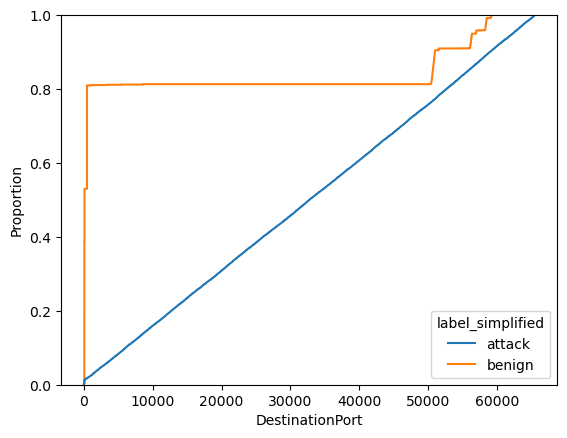

In [19]:
sns.ecdfplot(
    data = df,
    x = 'DestinationPort', # the column that you want to compute ecdf, they will be in the order from short to long length (numerical order)
    hue = 'label_simplified')

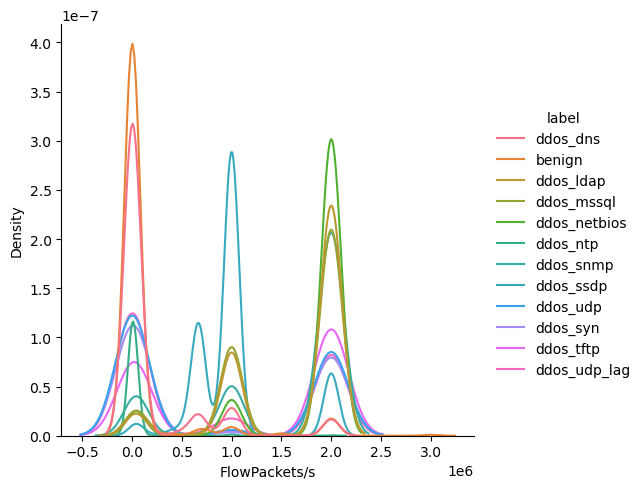

In [20]:
sns.displot(
    data = df, 
    x = "FlowPackets/s", # the column you want to check
    hue = "label", # check the distribution of different flower types
    kind = "kde" # a kernel density estimate (KDE) of the distribution, you can remove this to see the change
)

C:\Users\Mattia Pesce\AppData\Local\Temp\ipykernel_1736\1905931592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_masked['Timestamp'] = pd.to_datetime(df_masked['Timestamp'])


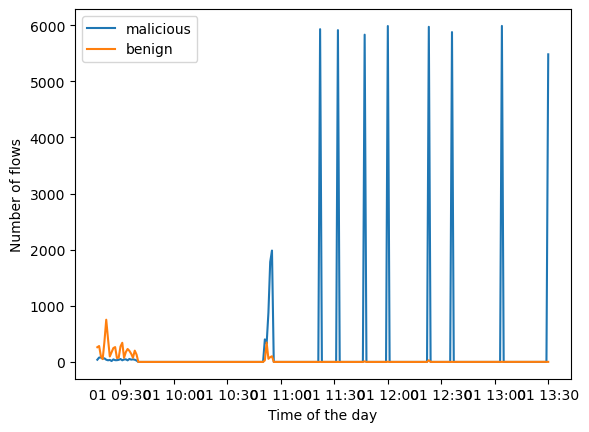

In [21]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_masked['Timestamp'] = pd.to_datetime(df_masked['Timestamp'])

df_time_b=df_masked.set_index('Timestamp')
df_time_b=df_time_b.resample('1min').size()

df_time=df.set_index('Timestamp')
df_time=df_time.resample('1min').size()
df_time_m=df_time-df_time_b

plt.figure()
sns.lineplot(data = df_time_m, label='malicious')
sns.lineplot(data = df_time_b,label='benign')
plt.xlabel("Time of the day")
plt.ylabel("Number of flows")
plt.show()

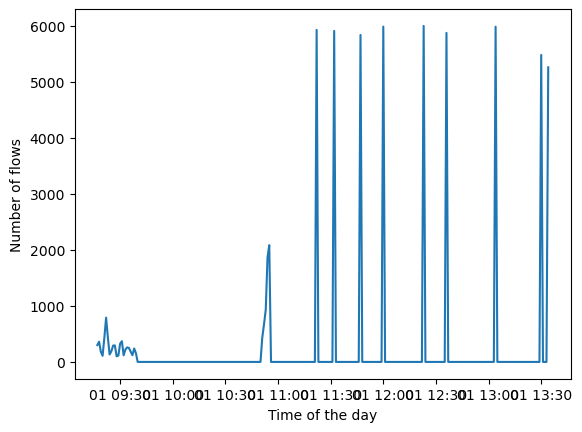

In [22]:
plt.figure()
sns.lineplot(data = df_time)
plt.xlabel("Time of the day")
plt.ylabel("Number of flows")
plt.show()

## 2. Generate additional features

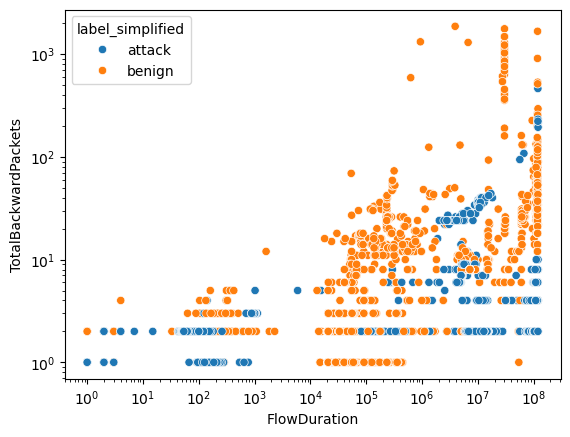

In [23]:
df['TotalBytes'] = df['TotalLengthofFwdPackets'] + df['TotalLengthofBwdPackets']
df['TotalPackets'] = df['TotalFwdPackets'] + df['TotalBackwardPackets']
df['AveragePacketLength'] = df['TotalBytes'] / df['TotalPackets']

df['Fwd/BwdPacketRatio'] = df['TotalFwdPackets'] / (df['TotalBackwardPackets'] + 1)

df['TrafficScore'] = df['TotalBytes'] * df['FlowPackets/s']

sns.scatterplot(
    data=df,
    x='FlowDuration',
    y='TotalBackwardPackets', # ????????
    hue='label_simplified') 
plt.xscale('log')
plt.yscale('log')
plt.show()

## 3. Data Pre-processing
### Categorial features encoding
#### Time

In [24]:
reference_date = min(df['Timestamp'])
df['Timestamp'] = (df['Timestamp'] - reference_date).dt.total_seconds()

In [25]:
df

,FlowID,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FlowDuration,TotalFwdPackets,TotalBackwardPackets,...,IdleMin,Inbound,label,ProtocolName,label_simplified,TotalBytes,TotalPackets,AveragePacketLength,Fwd/BwdPacketRatio,TrafficScore
0,172.16.0.5-192.168.50.1-634-60495-17,172.16.0.5,634,192.168.50.1,60495,17,5668.629638,28415,97,0,...,0.0,1,ddos_dns,UDP,attack,42680.0,97,440.0,97.0,1.456963e+08
1,192.168.50.1-172.16.0.5-634-60495-17,192.168.50.1,634,172.16.0.5,60495,17,5668.637032,2,2,0,...,0.0,0,ddos_dns,UDP,attack,880.0,2,440.0,2.0,8.800000e+08
2,172.16.0.5-192.168.50.1-634-46391-17,172.16.0.5,634,192.168.50.1,46391,17,5668.668689,48549,200,0,...,0.0,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,3.625203e+08
3,172.16.0.5-192.168.50.1-634-11894-17,172.16.0.5,634,192.168.50.1,11894,17,5668.706403,48337,200,0,...,0.0,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,3.641103e+08
4,172.16.0.5-192.168.50.1-634-27878-17,172.16.0.5,634,192.168.50.1,27878,17,5668.757341,32026,200,0,...,0.0,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,5.495535e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,172.16.0.5-192.168.50.1-38625-63051-17,172.16.0.5,38625,192.168.50.1,63051,17,13655.444439,1,2,0,...,0.0,1,ddos_udp_lag,UDP,attack,750.0,2,375.0,2.0,1.500000e+09
64235,172.16.0.5-192.168.50.1-58632-18963-17,172.16.0.5,58632,192.168.50.1,18963,17,13655.445153,212238,6,0,...,0.0,1,ddos_udp_lag,UDP,attack,2088.0,6,348.0,6.0,5.902807e+04
64236,172.16.0.5-192.168.50.1-46104-64704-17,172.16.0.5,46104,192.168.50.1,64704,17,13655.445204,1,2,0,...,0.0,1,ddos_udp_lag,UDP,attack,750.0,2,375.0,2.0,1.500000e+09
64237,172.16.0.5-192.168.50.1-60686-10440-17,172.16.0.5,60686,192.168.50.1,10440,17,13655.445206,108952,4,0,...,0.0,1,ddos_udp_lag,UDP,attack,1438.0,4,359.5,4.0,5.279389e+04


#### Source IP, Destination IP and label

In [26]:
categorical_features=['label','SourceIP','DestinationIP']

label_encoder = LabelEncoder()
for feature in categorical_features:
    if feature == 'label':
        df['IntLabel'] = label_encoder.fit_transform(df[feature])
    else:  
        df[feature] = label_encoder.fit_transform(df[feature])

df

,FlowID,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FlowDuration,TotalFwdPackets,TotalBackwardPackets,...,Inbound,label,ProtocolName,label_simplified,TotalBytes,TotalPackets,AveragePacketLength,Fwd/BwdPacketRatio,TrafficScore,IntLabel
0,172.16.0.5-192.168.50.1-634-60495-17,16,634,90,60495,17,5668.629638,28415,97,0,...,1,ddos_dns,UDP,attack,42680.0,97,440.0,97.0,1.456963e+08,1
1,192.168.50.1-172.16.0.5-634-60495-17,75,634,23,60495,17,5668.637032,2,2,0,...,0,ddos_dns,UDP,attack,880.0,2,440.0,2.0,8.800000e+08,1
2,172.16.0.5-192.168.50.1-634-46391-17,16,634,90,46391,17,5668.668689,48549,200,0,...,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,3.625203e+08,1
3,172.16.0.5-192.168.50.1-634-11894-17,16,634,90,11894,17,5668.706403,48337,200,0,...,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,3.641103e+08,1
4,172.16.0.5-192.168.50.1-634-27878-17,16,634,90,27878,17,5668.757341,32026,200,0,...,1,ddos_dns,UDP,attack,88000.0,200,440.0,200.0,5.495535e+08,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,172.16.0.5-192.168.50.1-38625-63051-17,16,38625,90,63051,17,13655.444439,1,2,0,...,1,ddos_udp_lag,UDP,attack,750.0,2,375.0,2.0,1.500000e+09,11
64235,172.16.0.5-192.168.50.1-58632-18963-17,16,58632,90,18963,17,13655.445153,212238,6,0,...,1,ddos_udp_lag,UDP,attack,2088.0,6,348.0,6.0,5.902807e+04,11
64236,172.16.0.5-192.168.50.1-46104-64704-17,16,46104,90,64704,17,13655.445204,1,2,0,...,1,ddos_udp_lag,UDP,attack,750.0,2,375.0,2.0,1.500000e+09,11
64237,172.16.0.5-192.168.50.1-60686-10440-17,16,60686,90,10440,17,13655.445206,108952,4,0,...,1,ddos_udp_lag,UDP,attack,1438.0,4,359.5,4.0,5.279389e+04,11


#### StandardScaler

In [27]:
labels=df[['IntLabel']].copy() #interi
label_df=df[['label']].copy()   #tutto ciò che non è intero
time=df[['Timestamp']].copy()
time.rename(columns={'Timestamp': 'Time'}, inplace=True)
tmp=df.drop(columns=['label','IntLabel','label_simplified','FlowID','ProtocolName'])

scaler=StandardScaler()
df_scale=scaler.fit_transform(tmp)
df_scale=pd.DataFrame(df_scale, columns=tmp.columns)

### Correlation matrix

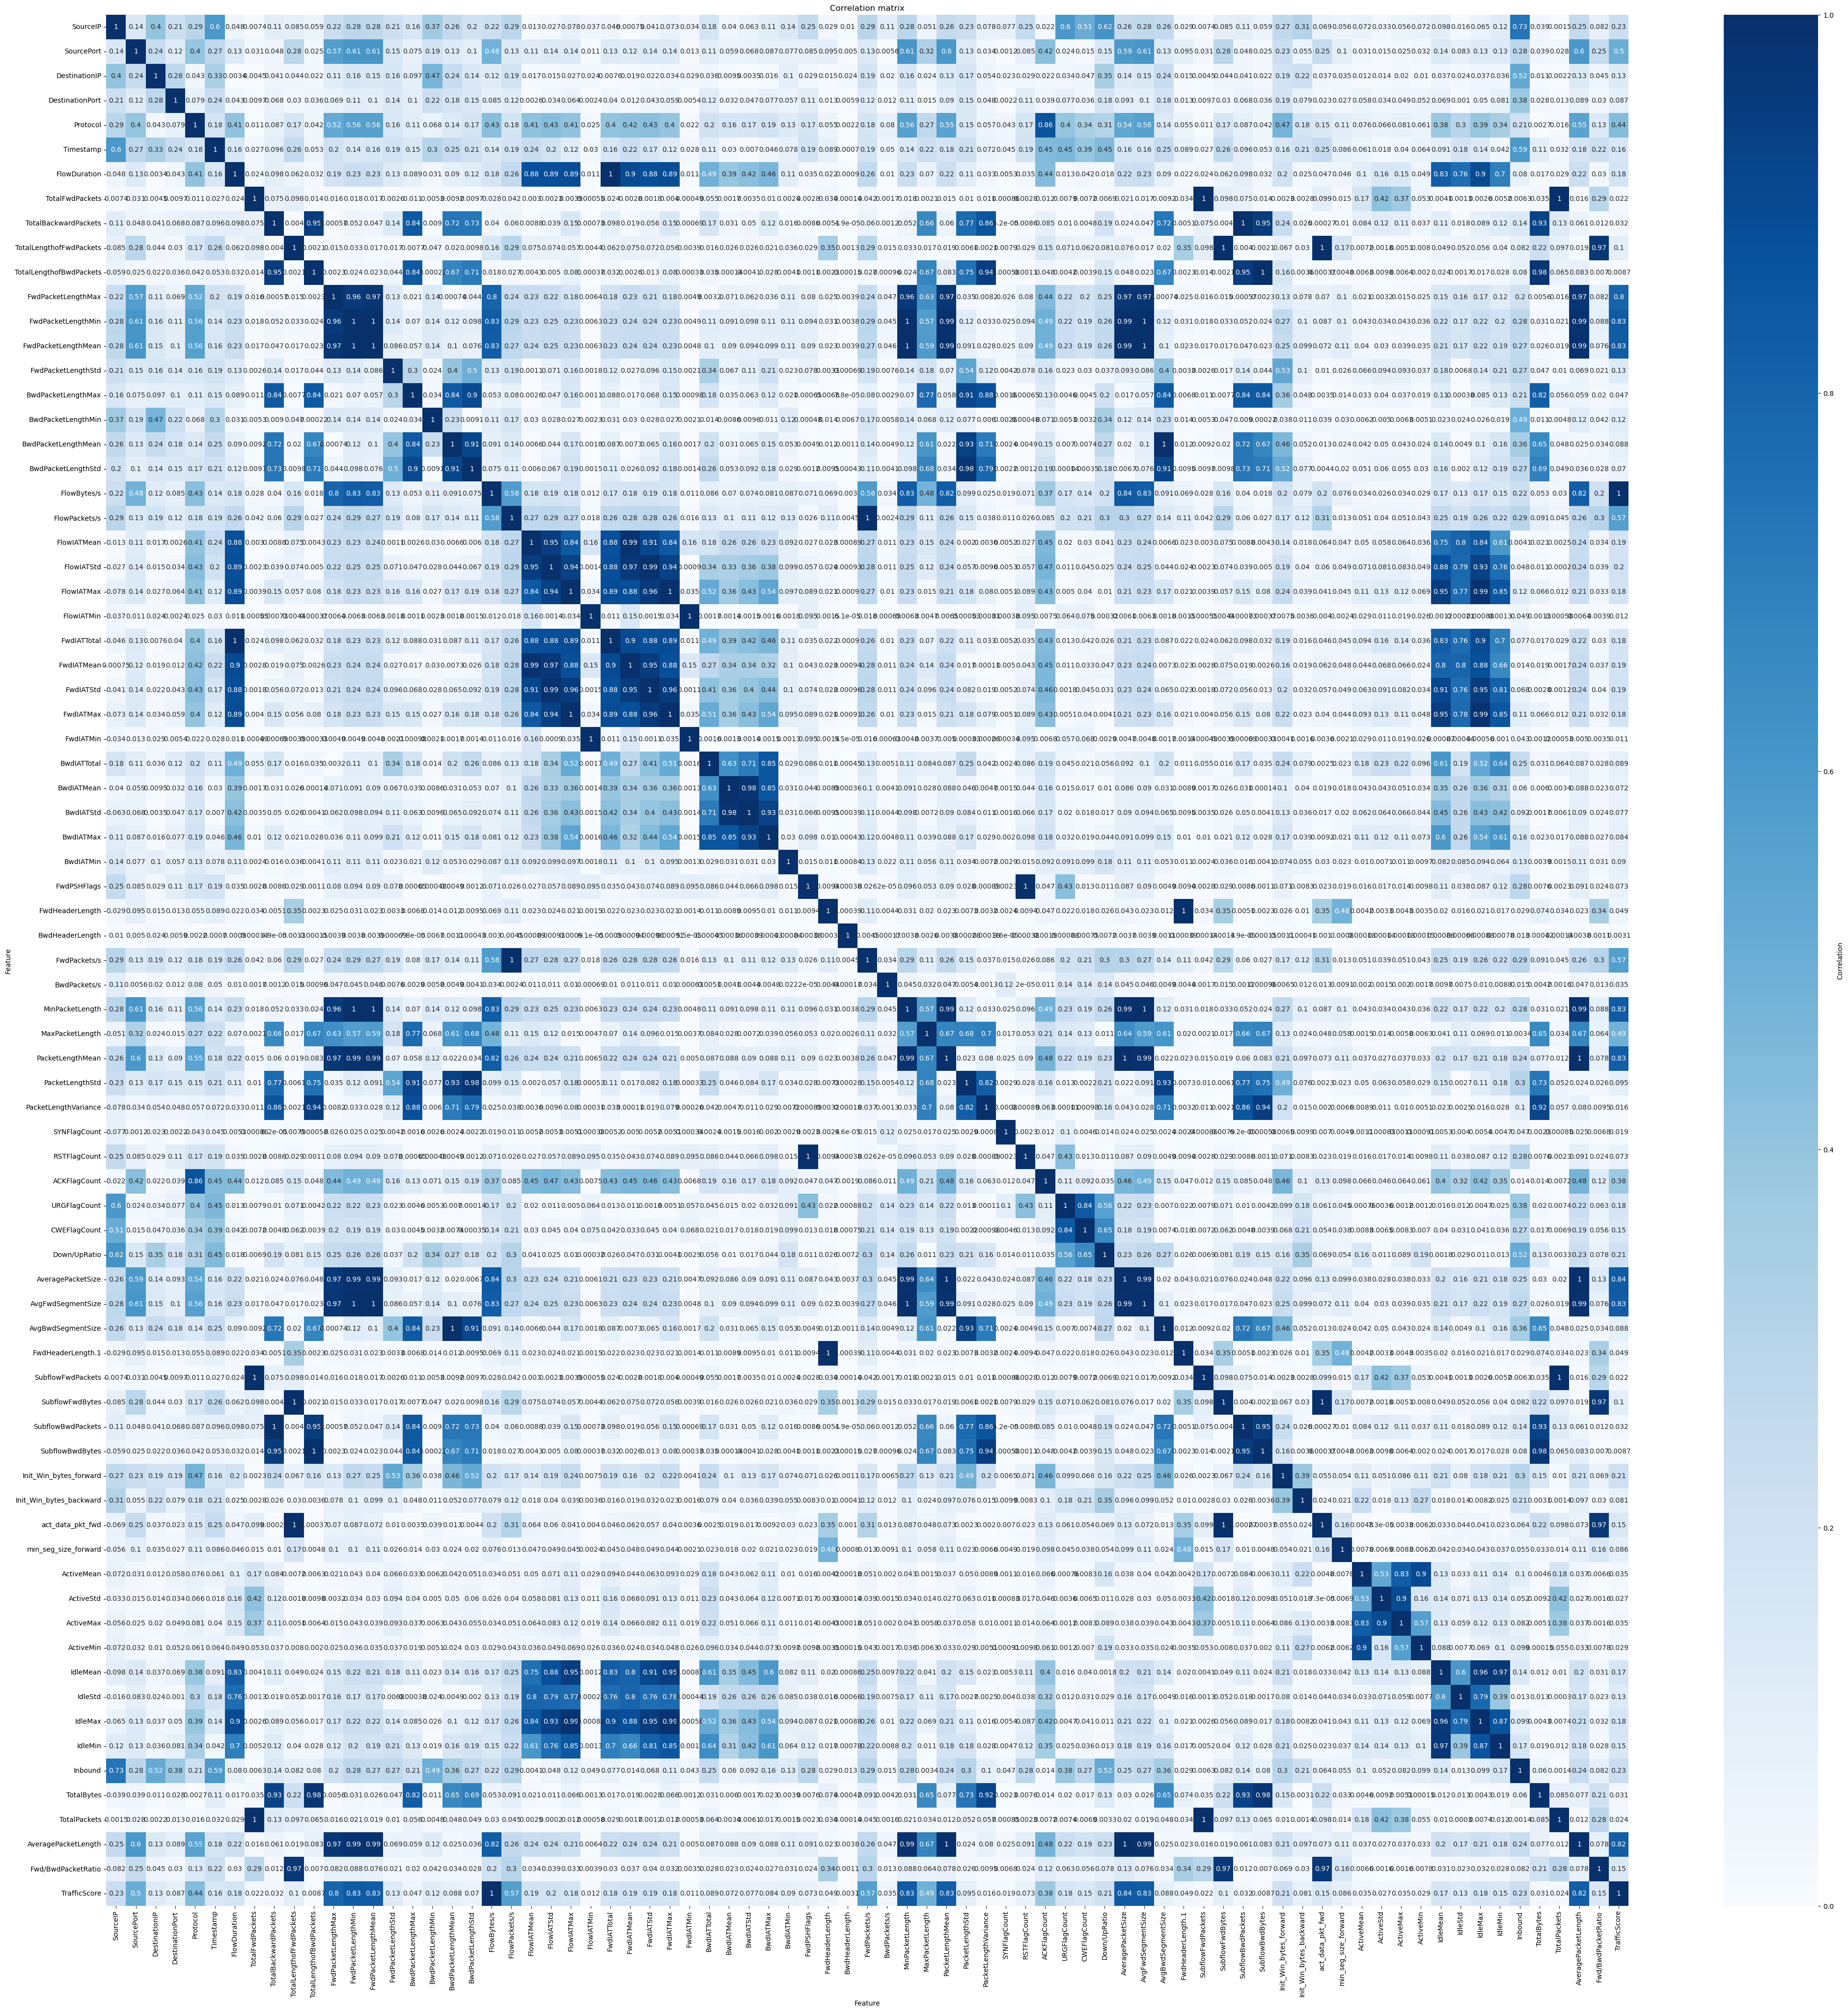

In [28]:
correlation_matrix = df_scale.corr().abs()

plt.figure(figsize=(50,50))
sns.heatmap(correlation_matrix, cmap='Blues', annot=True, vmin=.0, vmax=1, cbar_kws={'label':'Correlation'})
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.title('Correlation matrix')
plt.show()

In [29]:
# Extract features having a correlation > 0.8
c = correlation_matrix[correlation_matrix > 0.8]
s = c.unstack()
so = s.sort_values(ascending=False).reset_index()

# Get strongly correlatead features, removing pairs having correlation = 1 because of the diagonal, i.e., correlation between one feature and itself
so = so[(so[0].isnull()==False) & (so["level_0"] != so["level_1"])]
to_be_deleted = []
candidates = list(so["level_0"])

# Get the unique set of features to be deleted
# Notice that we discard one feature per time considering the case where a feature is strongly correlated with multiple features
subset_so = so
for candidate in candidates:
    if (candidate in list(subset_so["level_0"])): 
        to_be_deleted.append(candidate) # add the feature to the removed candidates
        subset_so = subset_so[(subset_so["level_0"] != candidate) & (subset_so["level_1"] != candidate)] # remove the rows that the removed feature is involved

print(len(to_be_deleted), 'features to be removed')

46 features to be removed


In [30]:
new_df = df_scale.copy()
new_df = new_df.drop(columns=to_be_deleted)
new_df

,SourceIP,SourcePort,DestinationIP,DestinationPort,Protocol,Timestamp,FwdPacketLengthMax,FwdPacketLengthStd,BwdPacketLengthMax,BwdPacketLengthMin,...,FwdHeaderLength.1,Init_Win_bytes_forward,Init_Win_bytes_backward,min_seg_size_forward,ActiveStd,IdleMean,IdleStd,Inbound,TotalPackets,Fwd/BwdPacketRatio
0,-0.294846,-0.996890,-0.156273,1.463534,0.560382,-0.981207,-0.297075,-0.172277,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,0.295752,0.165384,1.710894
1,2.322551,-0.996890,-2.966318,1.463534,0.560382,-0.981205,-0.297075,-0.172277,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,-3.381206,-0.038977,-0.261778
2,-0.294846,-0.996890,-0.156273,0.770389,0.560382,-0.981198,-0.297075,-0.172277,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,0.295752,0.386953,3.849685
3,-0.294846,-0.996890,-0.156273,-0.924976,0.560382,-0.981189,-0.297075,-0.172277,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,0.295752,0.386953,3.849685
4,-0.294846,-0.996890,-0.156273,-0.139438,0.560382,-0.981176,-0.297075,-0.172277,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,0.295752,0.386953,3.849685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64234,-0.294846,0.540571,-0.156273,1.589149,0.560382,0.942099,-0.408056,-0.172277,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,0.295752,-0.038977,-0.261778
64235,-0.294846,1.350236,-0.156273,-0.577568,0.560382,0.942099,-0.377323,0.521580,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,0.295752,-0.030372,-0.178718
64236,-0.294846,0.843239,-0.156273,1.670387,0.560382,0.942099,-0.408056,-0.172277,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,0.295752,-0.038977,-0.261778
64237,-0.294846,1.433360,-0.156273,-0.996433,0.560382,0.942099,-0.384152,0.501315,-0.069596,-0.146261,...,0.097732,-0.266314,-0.102881,0.202023,-0.034259,-0.216341,-0.165955,0.295752,-0.034674,-0.220248


### PCA

In [31]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(new_df)

PCA(random_state=42)

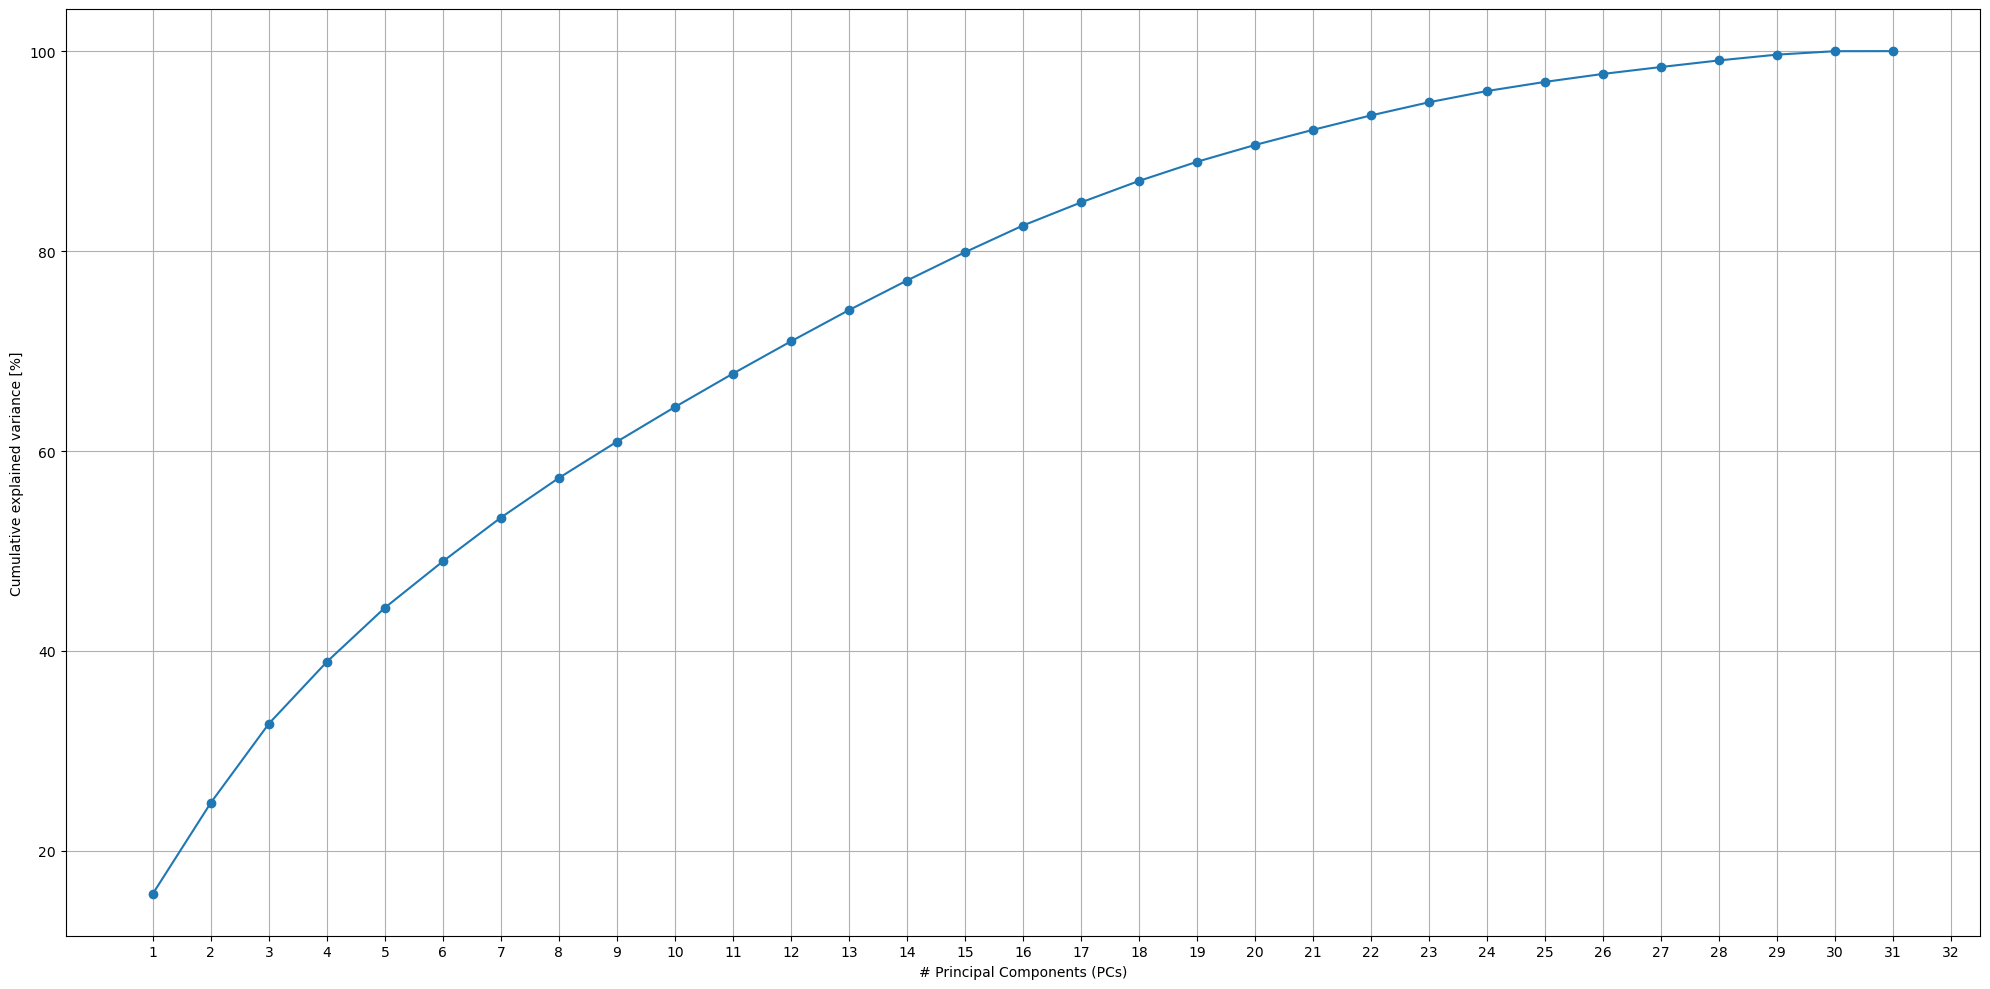

In [32]:
explained_variance = pca.explained_variance_ratio_
cumul_exp_var = np.cumsum(explained_variance)
perc_cumul_exp_var = cumul_exp_var * 100

plt.figure(figsize=(20, 10))
plt.plot(perc_cumul_exp_var, marker='o')
plt.xlabel('# Principal Components (PCs)')
plt.xticks([i for i in range(32)], [i for i in range(1,33)])
plt.ylabel('Cumulative explained variance [%]')
plt.grid()
plt.tight_layout()

perc_cumul_exp_var[19] = 89.49759008604823

this means that with 20 principal components the cumulative explained variance is nearly 90%

## 4. Characterize the new final feature matrix

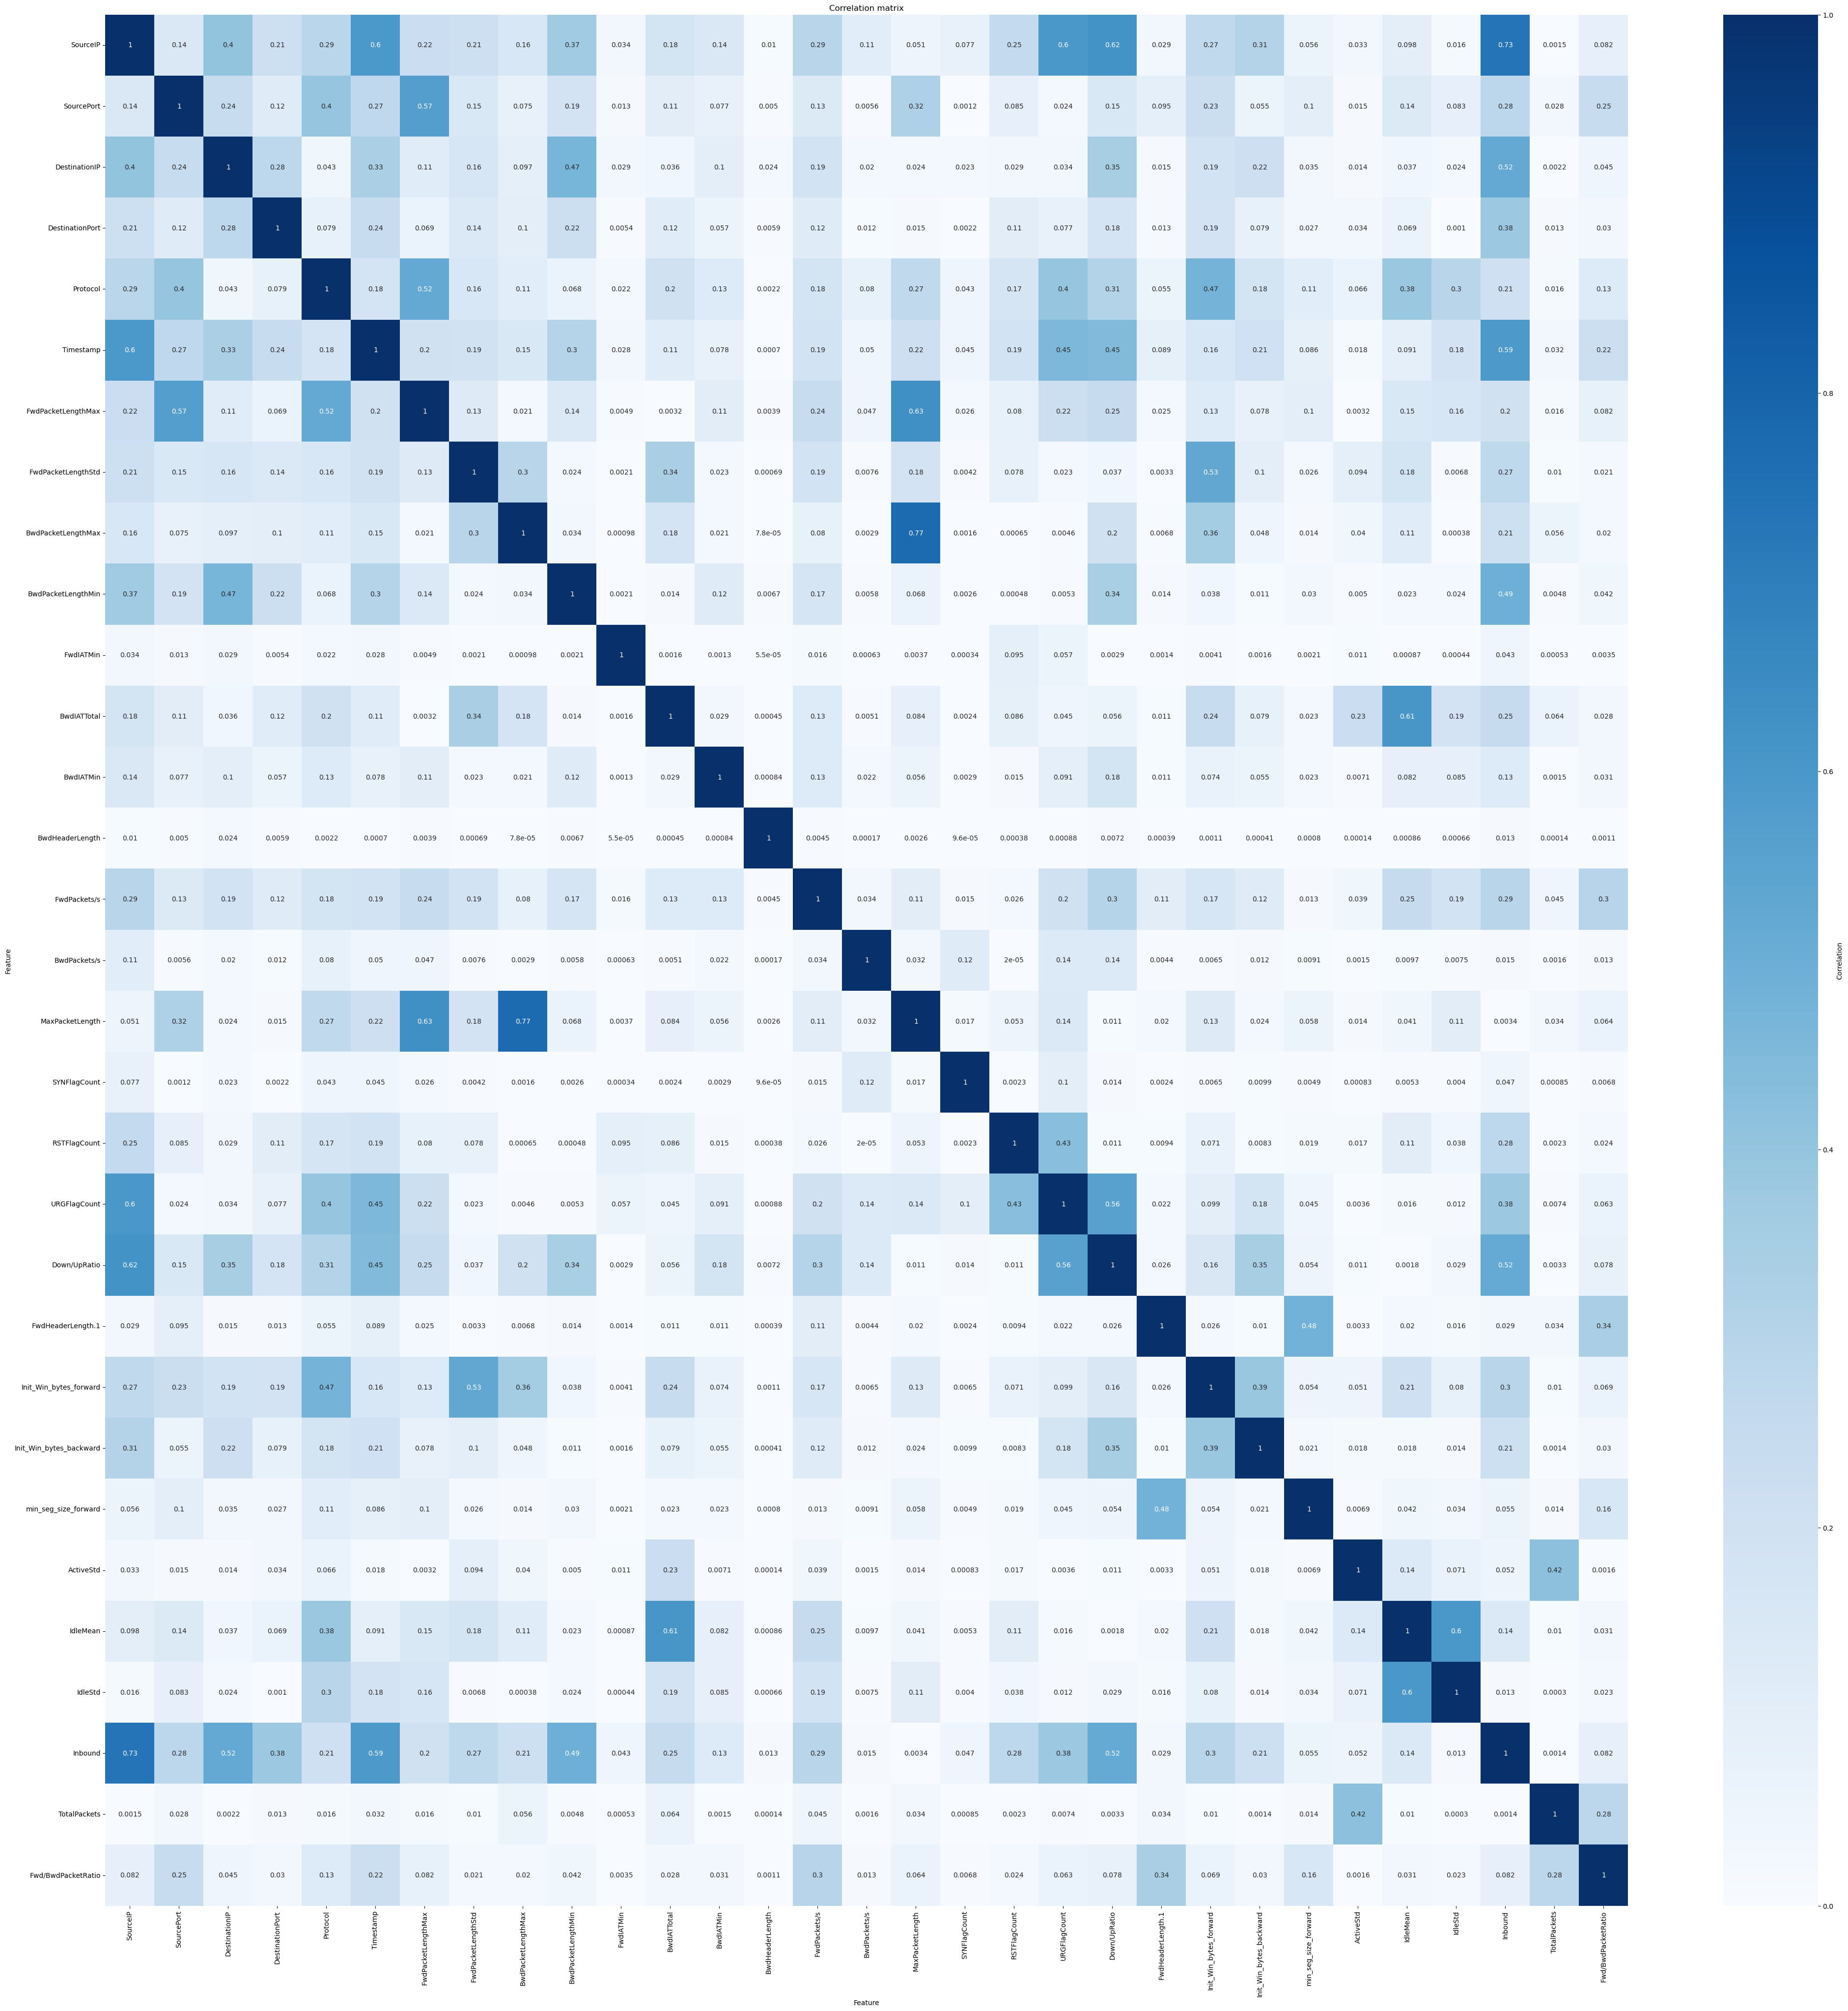

In [33]:
correlation_matrix = new_df.corr().abs()

plt.figure(figsize=(50,50))
sns.heatmap(correlation_matrix, cmap='Blues', annot=True, vmin=.0, vmax=1, cbar_kws={'label':'Correlation'})
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.title('Correlation matrix')
plt.show()

In [34]:
# producing plots regarding distributions of features (EPDF or ECDF)  ......

#### Section 2 –  Supervised learning – classification 
## 1. Train Test Split
### Label split

In [53]:
from sklearn.model_selection import train_test_split

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    new_df,
    labels[["IntLabel"]],
    stratify=labels["IntLabel"],
    train_size=0.7,
    random_state=42
)

### Temporal split

In [54]:
#new_df è quellos senza roba ridondante
#time è un vettore con il tempo
data = pd.concat([new_df, labels, time], axis=1)
groups = data.groupby('IntLabel')

train_fragments = []
test_fragments = []
for label, group in groups:
    sorted_group = group.sort_values(by='Time')
    g_train, g_test = train_test_split(sorted_group, train_size=0.7, shuffle=False)
    train_fragments.append(g_train)
    test_fragments.append(g_test)

train_df = pd.concat(train_fragments)
train_df.drop(columns=['Time'], inplace=True)
test_df = pd.concat(test_fragments)
test_df.drop(columns=['Time'], inplace=True)


#just a check
tmp_train = pd.concat([train_df[["IntLabel"]], time.loc[train_df.index].rename(columns={"Time":"Time"})], axis=1)
tmp_test  = pd.concat([test_df[["IntLabel"]],  time.loc[test_df.index].rename(columns={"Time":"Time"})], axis=1)

ok = (tmp_train.groupby("IntLabel")["Time"].max() < tmp_test.groupby("IntLabel")["Time"].min()).all()
print("Temporal split OK (train strictly earlier than test for each label):", ok)

Temporal split OK (train strictly earlier than test for each label): True


In [55]:
X_train_T = train_df.drop(columns=['IntLabel'])
y_train_T = train_df[['IntLabel']]
X_test_T = test_df.drop(columns=['IntLabel'])
y_test_T = test_df[['IntLabel']]

## 2. ML model Training and Evaluation for the two different splits

We choose 3 ML methods:
- SVM
- Random Forest
- k-Nearest Neighbors

### SVM

In [56]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# label split
svm_l = make_pipeline(StandardScaler(), SVC())
svm_l.fit(X_train_l, np.ravel(y_train_l))
y_predtrain_svm_l = svm_l.predict(X_train_l)
y_predtest_svm_l  = svm_l.predict(X_test_l)

# temporal split
svm_T = make_pipeline(StandardScaler(), SVC())
svm_T.fit(X_train_T, np.ravel(y_train_T))
y_predtrain_svm_T = svm_T.predict(X_train_T)
y_predtest_svm_T  = svm_T.predict(X_test_T)

In [57]:
from sklearn.metrics import f1_score
a=f1_score(y_test_l, y_predtest_svm_l, average='weighted')
b=f1_score(y_test_T, y_predtest_svm_T, average='weighted')

SVM train with label split 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3961
           1       1.00      1.00      1.00      3758
           2       0.97      1.00      0.99      4149
           3       1.00      0.97      0.98      4138
           4       1.00      1.00      1.00      4081
           5       1.00      1.00      1.00       690
           6       1.00      1.00      1.00      4189
           7       1.00      1.00      1.00      4179
           8       0.96      0.97      0.97      3836
           9       0.97      0.96      0.96      3683
          10       1.00      1.00      1.00      4113
          11       1.00      1.00      1.00      4190

    accuracy                           0.99     44967
   macro avg       0.99      0.99      0.99     44967
weighted avg       0.99      0.99      0.99     44967



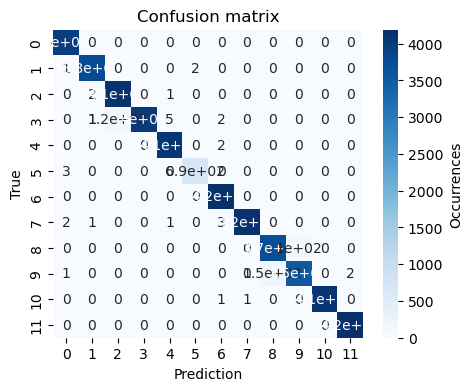


 SVM test with label split 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1697
           1       1.00      0.99      1.00      1611
           2       0.97      1.00      0.98      1779
           3       1.00      0.97      0.98      1773
           4       1.00      1.00      1.00      1749
           5       0.97      0.98      0.97       296
           6       1.00      1.00      1.00      1795
           7       1.00      1.00      1.00      1791
           8       0.95      0.98      0.96      1644
           9       0.98      0.95      0.96      1578
          10       1.00      1.00      1.00      1763
          11       1.00      1.00      1.00      1796

    accuracy                           0.99     19272
   macro avg       0.99      0.99      0.99     19272
weighted avg       0.99      0.99      0.99     19272



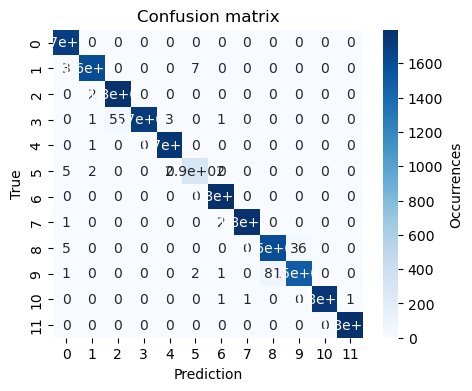

In [58]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# SVM with label split
print(f'SVM train with label split \n {classification_report(y_train_l, y_predtrain_svm_l)}')
confusion_train = confusion_matrix(y_train_l, y_predtrain_svm_l)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_train, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

print(f'\n SVM test with label split \n {classification_report(y_test_l, y_predtest_svm_l)}')
confusion_test = confusion_matrix(y_test_l, y_predtest_svm_l)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_test, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()


#togli la e+

SVM train with temporal split 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3960
           1       1.00      1.00      1.00      3758
           2       1.00      1.00      1.00      4149
           3       1.00      1.00      1.00      4137
           4       1.00      1.00      1.00      4080
           5       0.99      1.00      0.99       690
           6       1.00      1.00      1.00      4188
           7       1.00      1.00      1.00      4179
           8       0.95      0.97      0.96      3835
           9       0.97      0.95      0.96      3682
          10       1.00      1.00      1.00      4113
          11       1.00      1.00      1.00      4190

    accuracy                           0.99     44961
   macro avg       0.99      0.99      0.99     44961
weighted avg       0.99      0.99      0.99     44961



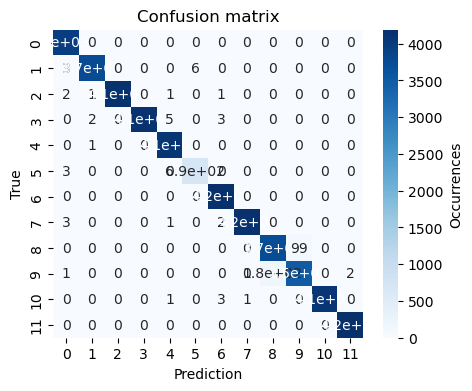


 SVM test with temporal split 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1698
           1       0.70      0.99      0.82      1611
           2       1.00      0.72      0.84      1779
           3       1.00      0.90      0.95      1774
           4       1.00      1.00      1.00      1750
           5       1.00      0.98      0.99       296
           6       1.00      1.00      1.00      1796
           7       1.00      1.00      1.00      1791
           8       0.96      0.97      0.97      1645
           9       0.97      0.96      0.97      1579
          10       1.00      1.00      1.00      1763
          11       1.00      1.00      1.00      1796

    accuracy                           0.96     19278
   macro avg       0.97      0.96      0.96     19278
weighted avg       0.97      0.96      0.96     19278



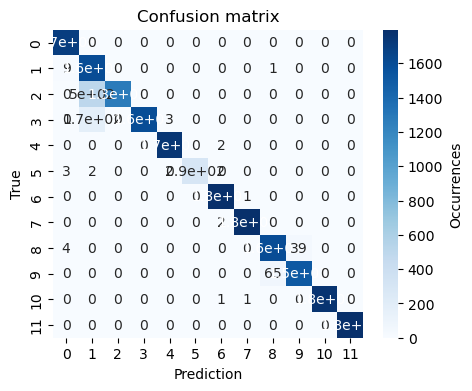

In [59]:
# SVM with temporal split
print(f'SVM train with temporal split \n {classification_report(y_train_T, y_predtrain_svm_T)}')
confusion_train = confusion_matrix(y_train_T, y_predtrain_svm_T)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_train, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

print(f'\n SVM test with temporal split \n {classification_report(y_test_T, y_predtest_svm_T)}')
confusion_test = confusion_matrix(y_test_T, y_predtest_svm_T)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_test, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

### Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier

# label split
rf_l=RandomForestClassifier()
rf_l.fit(X_train_l,np.ravel(y_train_l))
y_predtrain_rf_l=rf_l.predict(X_train_l)
y_predtest_rf_l=rf_l.predict(X_test_l)

# temporal split
rf_T=RandomForestClassifier()
rf_T.fit(X_train_T,np.ravel(y_train_T))
y_predtrain_rf_T=rf_T.predict(X_train_T)
y_predtest_rf_T=rf_T.predict(X_test_T)

In [61]:
c=f1_score(y_test_l, y_predtest_rf_l, average='weighted')
d=f1_score(y_test_T, y_predtest_rf_T, average='weighted')

RF train with label split 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3961
           1       1.00      1.00      1.00      3758
           2       1.00      1.00      1.00      4149
           3       1.00      1.00      1.00      4138
           4       1.00      1.00      1.00      4081
           5       1.00      1.00      1.00       690
           6       1.00      1.00      1.00      4189
           7       1.00      1.00      1.00      4179
           8       1.00      1.00      1.00      3836
           9       1.00      1.00      1.00      3683
          10       1.00      1.00      1.00      4113
          11       1.00      1.00      1.00      4190

    accuracy                           1.00     44967
   macro avg       1.00      1.00      1.00     44967
weighted avg       1.00      1.00      1.00     44967



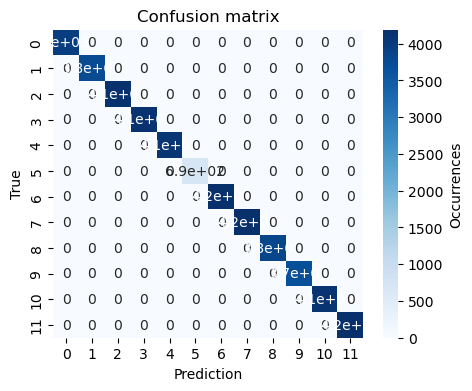


 RF test with label split 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1697
           1       1.00      1.00      1.00      1611
           2       1.00      1.00      1.00      1779
           3       1.00      1.00      1.00      1773
           4       1.00      1.00      1.00      1749
           5       1.00      0.99      0.99       296
           6       1.00      1.00      1.00      1795
           7       1.00      1.00      1.00      1791
           8       1.00      1.00      1.00      1644
           9       1.00      1.00      1.00      1578
          10       1.00      1.00      1.00      1763
          11       1.00      1.00      1.00      1796

    accuracy                           1.00     19272
   macro avg       1.00      1.00      1.00     19272
weighted avg       1.00      1.00      1.00     19272



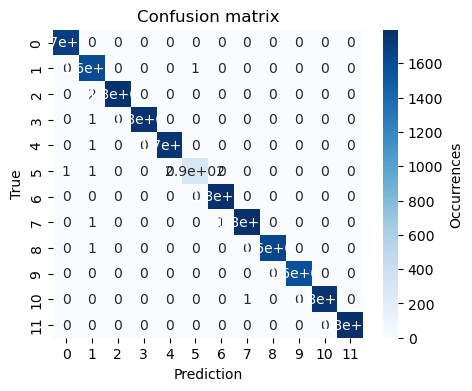

In [62]:
# Random Forest with label split
print(f'RF train with label split \n {classification_report(y_train_l, y_predtrain_rf_l)}')
confusion_train = confusion_matrix(y_train_l, y_predtrain_rf_l)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_train, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

print(f'\n RF test with label split \n {classification_report(y_test_l, y_predtest_rf_l)}')
confusion_test = confusion_matrix(y_test_l, y_predtest_rf_l)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_test, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

RF train with temporal split 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3960
           1       1.00      1.00      1.00      3758
           2       1.00      1.00      1.00      4149
           3       1.00      1.00      1.00      4137
           4       1.00      1.00      1.00      4080
           5       1.00      1.00      1.00       690
           6       1.00      1.00      1.00      4188
           7       1.00      1.00      1.00      4179
           8       1.00      1.00      1.00      3835
           9       1.00      1.00      1.00      3682
          10       1.00      1.00      1.00      4113
          11       1.00      1.00      1.00      4190

    accuracy                           1.00     44961
   macro avg       1.00      1.00      1.00     44961
weighted avg       1.00      1.00      1.00     44961



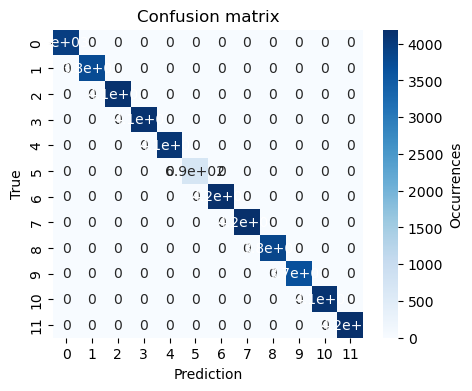


 RF test with temporal split 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1698
           1       0.81      1.00      0.89      1611
           2       1.00      0.79      0.88      1779
           3       1.00      1.00      1.00      1774
           4       1.00      1.00      1.00      1750
           5       1.00      0.99      1.00       296
           6       1.00      1.00      1.00      1796
           7       1.00      1.00      1.00      1791
           8       1.00      1.00      1.00      1645
           9       1.00      1.00      1.00      1579
          10       1.00      1.00      1.00      1763
          11       1.00      1.00      1.00      1796

    accuracy                           0.98     19278
   macro avg       0.98      0.98      0.98     19278
weighted avg       0.98      0.98      0.98     19278



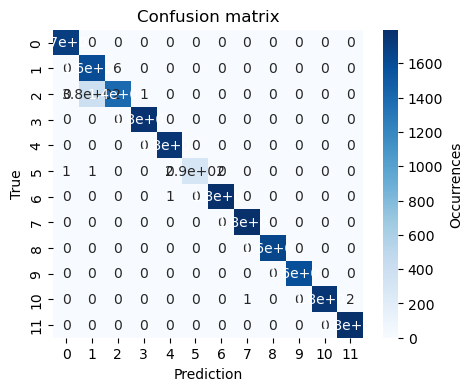

In [63]:
# Random Forest with temporal split
print(f'RF train with temporal split \n {classification_report(y_train_T, y_predtrain_rf_T)}')
confusion_train = confusion_matrix(y_train_T, y_predtrain_rf_T)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_train, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

print(f'\n RF test with temporal split \n {classification_report(y_test_T, y_predtest_rf_T)}')
confusion_test = confusion_matrix(y_test_T, y_predtest_rf_T)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_test, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

###  k-Nearest Neighbors

In [64]:
from sklearn.neighbors import KNeighborsClassifier

# label split
knn_l = make_pipeline(StandardScaler(), KNeighborsClassifier())
knn_l.fit(X_train_l,np.ravel(y_train_l))
y_predtrain_knn_l=knn_l.predict(X_train_l)
y_predtest_knn_l=knn_l.predict(X_test_l)

# temporal split
knn_T = make_pipeline(StandardScaler(), KNeighborsClassifier())
knn_T.fit(X_train_T,np.ravel(y_train_T))
y_predtrain_knn_T=knn_T.predict(X_train_T)
y_predtest_knn_T=knn_T.predict(X_test_T)

In [65]:
from sklearn.metrics import f1_score
e=f1_score(y_test_l, y_predtest_knn_l, average='weighted')
f=f1_score(y_test_T, y_predtest_knn_T, average='weighted')

k-NN train with label split 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      3961
           1       1.00      0.99      0.99      3758
           2       0.99      0.99      0.99      4149
           3       1.00      0.99      0.99      4138
           4       1.00      1.00      1.00      4081
           5       0.98      0.98      0.98       690
           6       1.00      1.00      1.00      4189
           7       1.00      1.00      1.00      4179
           8       0.99      0.99      0.99      3836
           9       0.99      0.99      0.99      3683
          10       1.00      1.00      1.00      4113
          11       1.00      1.00      1.00      4190

    accuracy                           1.00     44967
   macro avg       0.99      0.99      0.99     44967
weighted avg       1.00      1.00      1.00     44967



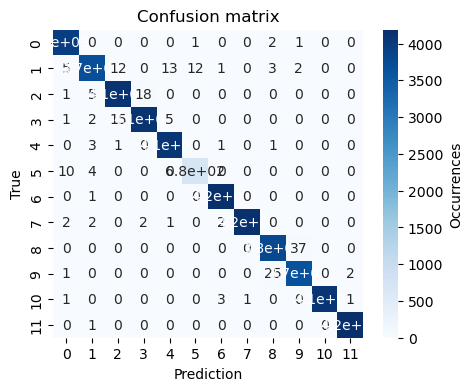


 k-NN test with label split 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1697
           1       0.99      0.98      0.98      1611
           2       0.99      0.99      0.99      1779
           3       0.99      0.98      0.99      1773
           4       0.99      1.00      1.00      1749
           5       0.93      0.97      0.95       296
           6       1.00      1.00      1.00      1795
           7       1.00      1.00      1.00      1791
           8       0.99      0.99      0.99      1644
           9       0.99      0.99      0.99      1578
          10       1.00      1.00      1.00      1763
          11       1.00      1.00      1.00      1796

    accuracy                           0.99     19272
   macro avg       0.99      0.99      0.99     19272
weighted avg       0.99      0.99      0.99     19272



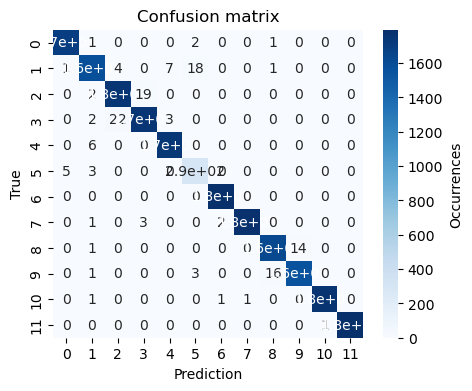

In [66]:
# k-Nearest Neighbors with label split
print(f'k-NN train with label split \n {classification_report(y_train_l, y_predtrain_knn_l)}')
confusion_train = confusion_matrix(y_train_l, y_predtrain_knn_l)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_train, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

print(f'\n k-NN test with label split \n {classification_report(y_test_l, y_predtest_knn_l)}')
confusion_test = confusion_matrix(y_test_l, y_predtest_knn_l)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_test, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

k-NN train with temporal split 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      3960
           1       0.99      0.99      0.99      3758
           2       1.00      0.99      1.00      4149
           3       1.00      1.00      1.00      4137
           4       1.00      1.00      1.00      4080
           5       0.97      0.98      0.97       690
           6       1.00      1.00      1.00      4188
           7       1.00      1.00      1.00      4179
           8       0.99      0.99      0.99      3835
           9       0.99      0.99      0.99      3682
          10       1.00      1.00      1.00      4113
          11       1.00      1.00      1.00      4190

    accuracy                           1.00     44961
   macro avg       0.99      0.99      0.99     44961
weighted avg       1.00      1.00      1.00     44961



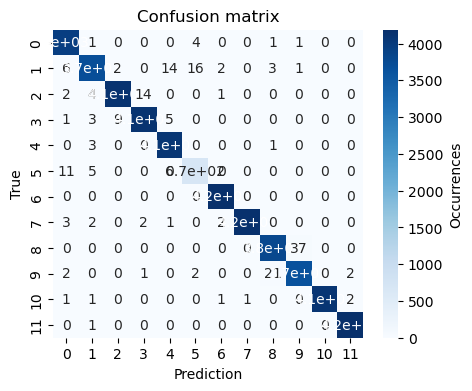


 k-NN test with temporal split 
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1698
           1       0.87      0.98      0.92      1611
           2       0.99      0.72      0.83      1779
           3       1.00      0.90      0.94      1774
           4       0.99      1.00      1.00      1750
           5       0.97      0.99      0.98       296
           6       1.00      1.00      1.00      1796
           7       0.80      1.00      0.89      1791
           8       0.99      0.99      0.99      1645
           9       0.99      0.99      0.99      1579
          10       1.00      1.00      1.00      1763
          11       1.00      1.00      1.00      1796

    accuracy                           0.96     19278
   macro avg       0.97      0.96      0.96     19278
weighted avg       0.97      0.96      0.96     19278



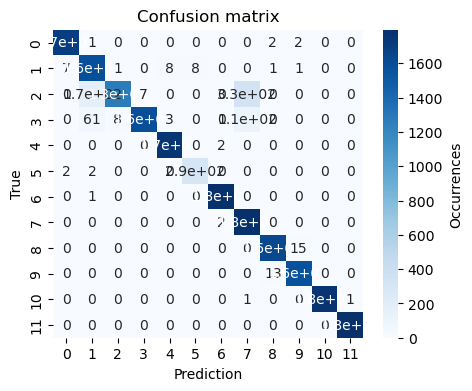

In [67]:
# k-Nearest Neighbors with temporal split
print(f'k-NN train with temporal split \n {classification_report(y_train_T, y_predtrain_knn_T)}')
confusion_train = confusion_matrix(y_train_T, y_predtrain_knn_T)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_train, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

print(f'\n k-NN test with temporal split \n {classification_report(y_test_T, y_predtest_knn_T)}')
confusion_test = confusion_matrix(y_test_T, y_predtest_knn_T)

# visualize the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_test, cmap='Blues', annot=True, cbar_kws={'label':'Occurrences'})
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

Which model generates the best performance? Random Forest

Why does the performance vary among different attacks? .......

In [68]:
print("Weighted F1 (Label split)   - SVM:", a, " RF:", c, " kNN:", e)
print("Weighted F1 (Temporal split)- SVM:", b, " RF:", d, " kNN:", f)


Weighted F1 (Label split)   - SVM: 0.9889857486812966  RF: 0.9994294117941404  kNN: 0.9926459106672919
Weighted F1 (Temporal split)- SVM: 0.9588698433312783  RF: 0.9795310173842721  kNN: 0.9597753341581361


In [70]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def summarize_train_test(y_train_df, y_pred_train, y_test_df, y_pred_test):
    y_train = np.ravel(y_train_df)
    y_test  = np.ravel(y_test_df)

    out = {
        "train_acc": accuracy_score(y_train, y_pred_train),
        "test_acc":  accuracy_score(y_test,  y_pred_test),

        "train_f1w": f1_score(y_train, y_pred_train, average="weighted"),
        "test_f1w":  f1_score(y_test,  y_pred_test,  average="weighted"),

        "train_f1macro": f1_score(y_train, y_pred_train, average="macro"),
        "test_f1macro":  f1_score(y_test,  y_pred_test,  average="macro"),
    }

    out["gap_acc"] = out["train_acc"] - out["test_acc"]
    out["gap_f1w"] = out["train_f1w"] - out["test_f1w"]
    out["gap_f1macro"] = out["train_f1macro"] - out["test_f1macro"]
    return out


baseline_rows = []

# LABEL split
baseline_rows.append({"split":"per-flow", "model":"SVM", **summarize_train_test(y_train_l, y_predtrain_svm_l, y_test_l, y_predtest_svm_l)})
baseline_rows.append({"split":"per-flow", "model":"RF",  **summarize_train_test(y_train_l, y_predtrain_rf_l,  y_test_l, y_predtest_rf_l)})
baseline_rows.append({"split":"per-flow", "model":"kNN", **summarize_train_test(y_train_l, y_predtrain_knn_l, y_test_l, y_predtest_knn_l)})

# TEMPORAL split
baseline_rows.append({"split":"per-time", "model":"SVM", **summarize_train_test(y_train_T, y_predtrain_svm_T, y_test_T, y_predtest_svm_T)})
baseline_rows.append({"split":"per-time", "model":"RF",  **summarize_train_test(y_train_T, y_predtrain_rf_T,  y_test_T, y_predtest_rf_T)})
baseline_rows.append({"split":"per-time", "model":"kNN", **summarize_train_test(y_train_T, y_predtrain_knn_T, y_test_T, y_predtest_knn_T)})

df_overfit = pd.DataFrame(baseline_rows)
df_overfit = df_overfit.sort_values(["split","test_f1w"], ascending=[True, False])
display(df_overfit)

,split,model,train_acc,test_acc,train_f1w,test_f1w,train_f1macro,test_f1macro,gap_acc,gap_f1w,gap_f1macro
1,per-flow,RF,1.000000,0.999429,1.000000,0.999429,1.000000,0.999110,0.000571,0.000571,0.000890
2,per-flow,kNN,0.995530,0.992632,0.995529,0.992646,0.994374,0.989508,0.002898,0.002883,0.004867
0,per-flow,SVM,0.990927,0.989000,0.990921,0.988986,0.990988,0.987526,0.001927,0.001935,0.003462
4,per-time,RF,1.000000,0.979666,1.000000,0.979531,1.000000,0.980434,0.020334,0.020469,0.019566
5,per-time,kNN,0.995730,0.960525,0.995730,0.959775,0.994016,0.961563,0.035205,0.035955,0.032452
3,per-time,SVM,0.992927,0.958191,0.992924,0.958870,0.992554,0.960331,0.034737,0.034054,0.032222


In [71]:
def interpret_fit(row, f1_gap_thr=0.05, low_f1_thr=0.70):
    # heuristic
    if row["gap_f1w"] > f1_gap_thr:
        return "Likely OVERFITTING (train >> test)"
    if row["train_f1w"] < low_f1_thr and row["test_f1w"] < low_f1_thr:
        return "Likely UNDERFITTING (both low)"
    return "No strong signal (or distribution shift)"

df_overfit["fit_comment"] = df_overfit.apply(interpret_fit, axis=1)
display(df_overfit[["split","model","train_f1w","test_f1w","gap_f1w","fit_comment"]])


,split,model,train_f1w,test_f1w,gap_f1w,fit_comment
1,per-flow,RF,1.000000,0.999429,0.000571,No strong signal (or distribution shift)
2,per-flow,kNN,0.995529,0.992646,0.002883,No strong signal (or distribution shift)
0,per-flow,SVM,0.990921,0.988986,0.001935,No strong signal (or distribution shift)
4,per-time,RF,1.000000,0.979531,0.020469,No strong signal (or distribution shift)
5,per-time,kNN,0.995730,0.959775,0.035955,No strong signal (or distribution shift)
3,per-time,SVM,0.992924,0.958870,0.034054,No strong signal (or distribution shift)


In [ ]:
#1.c
from sklearn.model_selection import validation_curve, StratifiedKFold


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def val_curve(model, X_train, y_train_df, param_name, param_range, title, logx=False):
    y_train = np.ravel(y_train_df)

    train_scores, val_scores = validation_curve(
        model, X_train, y_train,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)

    best_idx = int(np.argmax(val_mean))
    best_param = param_range[best_idx]
    best_val = val_mean[best_idx]

    plt.figure(figsize=(10, 6))
    if logx:
        plt.semilogx(param_range, train_mean, label="Training score", marker='o')
        plt.semilogx(param_range, val_mean, label="Validation score", marker='o')
    else:
        plt.plot(param_range, train_mean, label="Training score", marker='o')
        plt.plot(param_range, val_mean, label="Validation score", marker='o')

    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    return best_param, float(best_val)


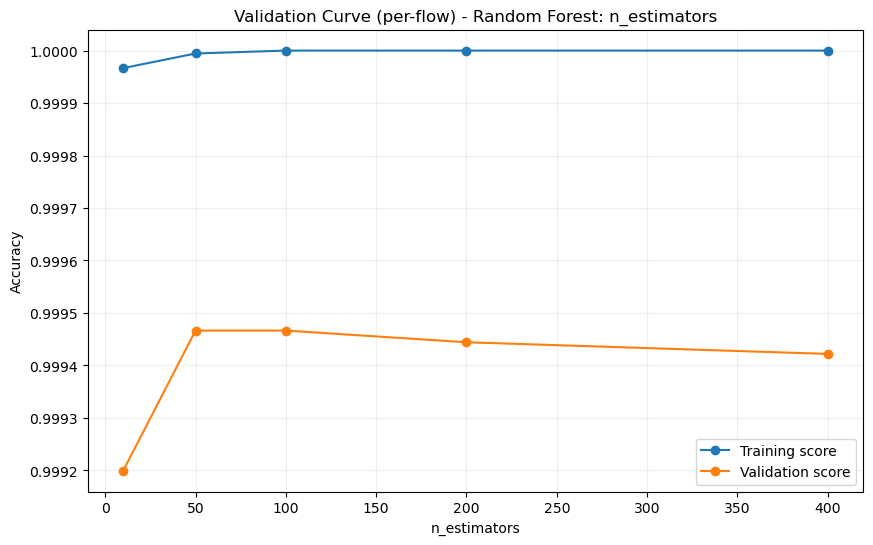

Best RF n_estimators: 50 | Best CV accuracy: 0.999466263892498


In [78]:
#Random forest validation curve (n_estimators)
rf_param_range = [1, 5, 10, 30, 50, 80]

best_rf_n, best_rf_acc = val_curve(
    RandomForestClassifier(random_state=42),
    X_train_l, y_train_l,
    param_name="n_estimators",
    param_range=rf_param_range,
    title="Validation Curve for Random Forest with label split"
)

print("Best RF n_estimators:", best_rf_n, "| f1-score:", best_rf_acc)


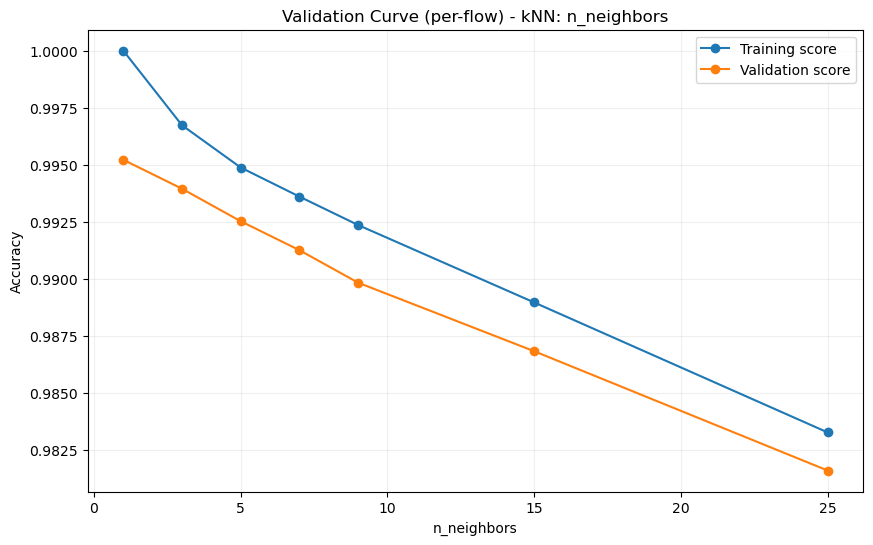

Best kNN n_neighbors: 1 | Best CV accuracy: 0.9952187109876505


In [79]:
knn_param_range = [1, 3, 5, 7, 9, 15, 25]

best_knn_k, best_knn_acc = val_curve(
    KNeighborsClassifier(),
    X_train_l, y_train_l,
    param_name="n_neighbors",
    param_range=knn_param_range,
    title="Validation Curve (per-flow) - kNN: n_neighbors"
)

print("Best kNN n_neighbors:", best_knn_k, "| Best CV accuracy:", best_knn_acc)


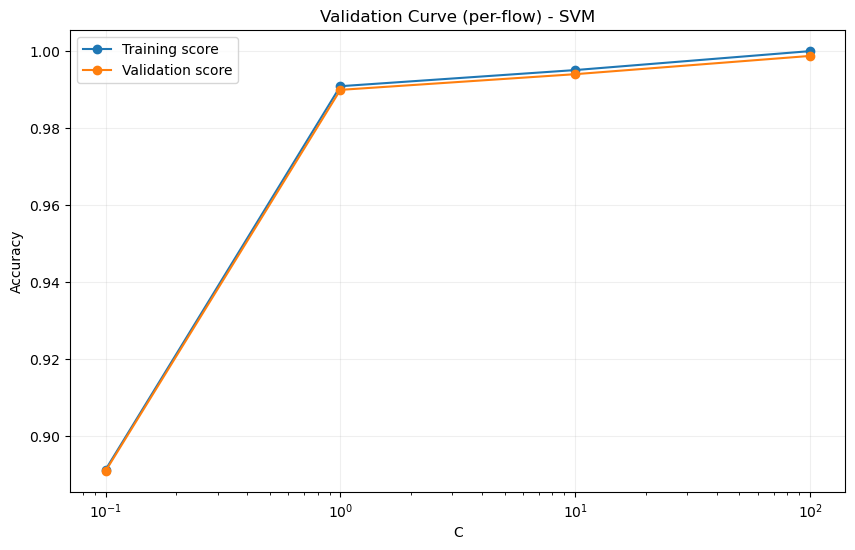

Best SVM C: 100 | Best CV accuracy: 0.9987101597885004


In [82]:
#SVM validation curve
svm_param_range = [0.1, 1, 10, 100]

best_svm_c, best_svm_acc = val_curve(
    SVC(),
    X_train_l, y_train_l,
    param_name="C",
    param_range=svm_param_range,
    title="Validation Curve (per-flow) - SVM",
    logx=True
)

print("Best SVM C:", best_svm_c, "| Best CV accuracy:", best_svm_acc)


RF has best CV accuracy (~0.999466), higher than SVM (~0.998710) and kNN (~0.995219).

- RF curve: ~33 s
- kNN curve: ~1 min 17 s
- SVM curve: ~4 min 34 s

So RF is also the best tradeoff: highest accuracy and lowest tuning time among the three in your run.
RF is the choice beacuse it reaches near-perfect validation performance quickly (plateau after 50 trees), and extra trees don’t improve results enough to justify extra time.

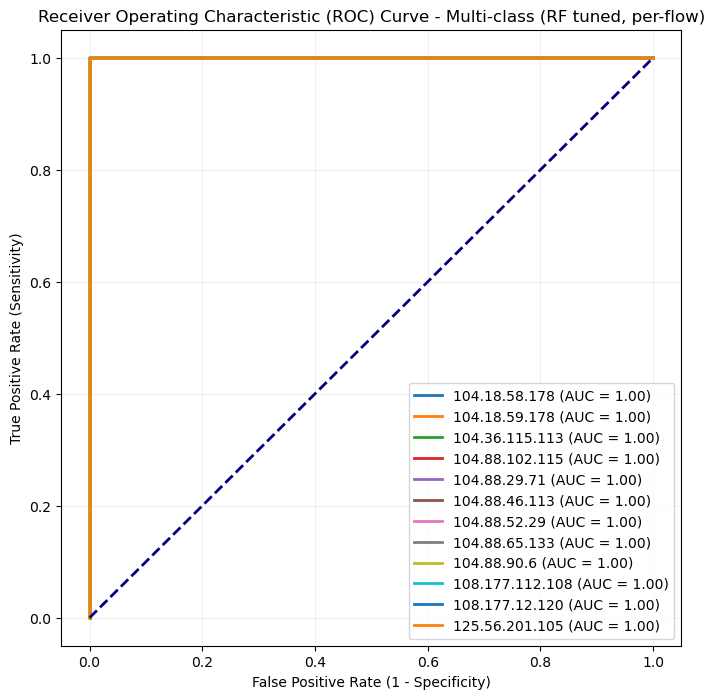

In [89]:
from sklearn.metrics import roc_curve, auc


# Train BEST RF (from your CV): n_estimators=50
rf_final = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_final.fit(X_train_l, np.ravel(y_train_l))

# Test data (per-flow)
y_test = np.ravel(y_test_l)
X_test = X_test_l

# Predict probabilities
y_proba = rf_final.predict_proba(X_test)

# Classes present in test
classes = np.unique(y_test)

plt.figure(figsize=(8, 8))

# rf_final.classes_ tells which column corresponds to which class label
model_classes = rf_final.classes_

for c in classes:
    # True binary labels for class c (one-vs-rest)
    y_true_bin = (y_test == c).astype(int)

    # Find the column of probabilities for class c
    col_idx = np.where(model_classes == c)[0][0]
    y_score = y_proba[:, col_idx]

    # ROC + AUC
    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)

    # Class name (string)
    class_name = label_encoder.inverse_transform([c])[0]

    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

# Diagonal line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-class (RF tuned, per-flow)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)
plt.show()

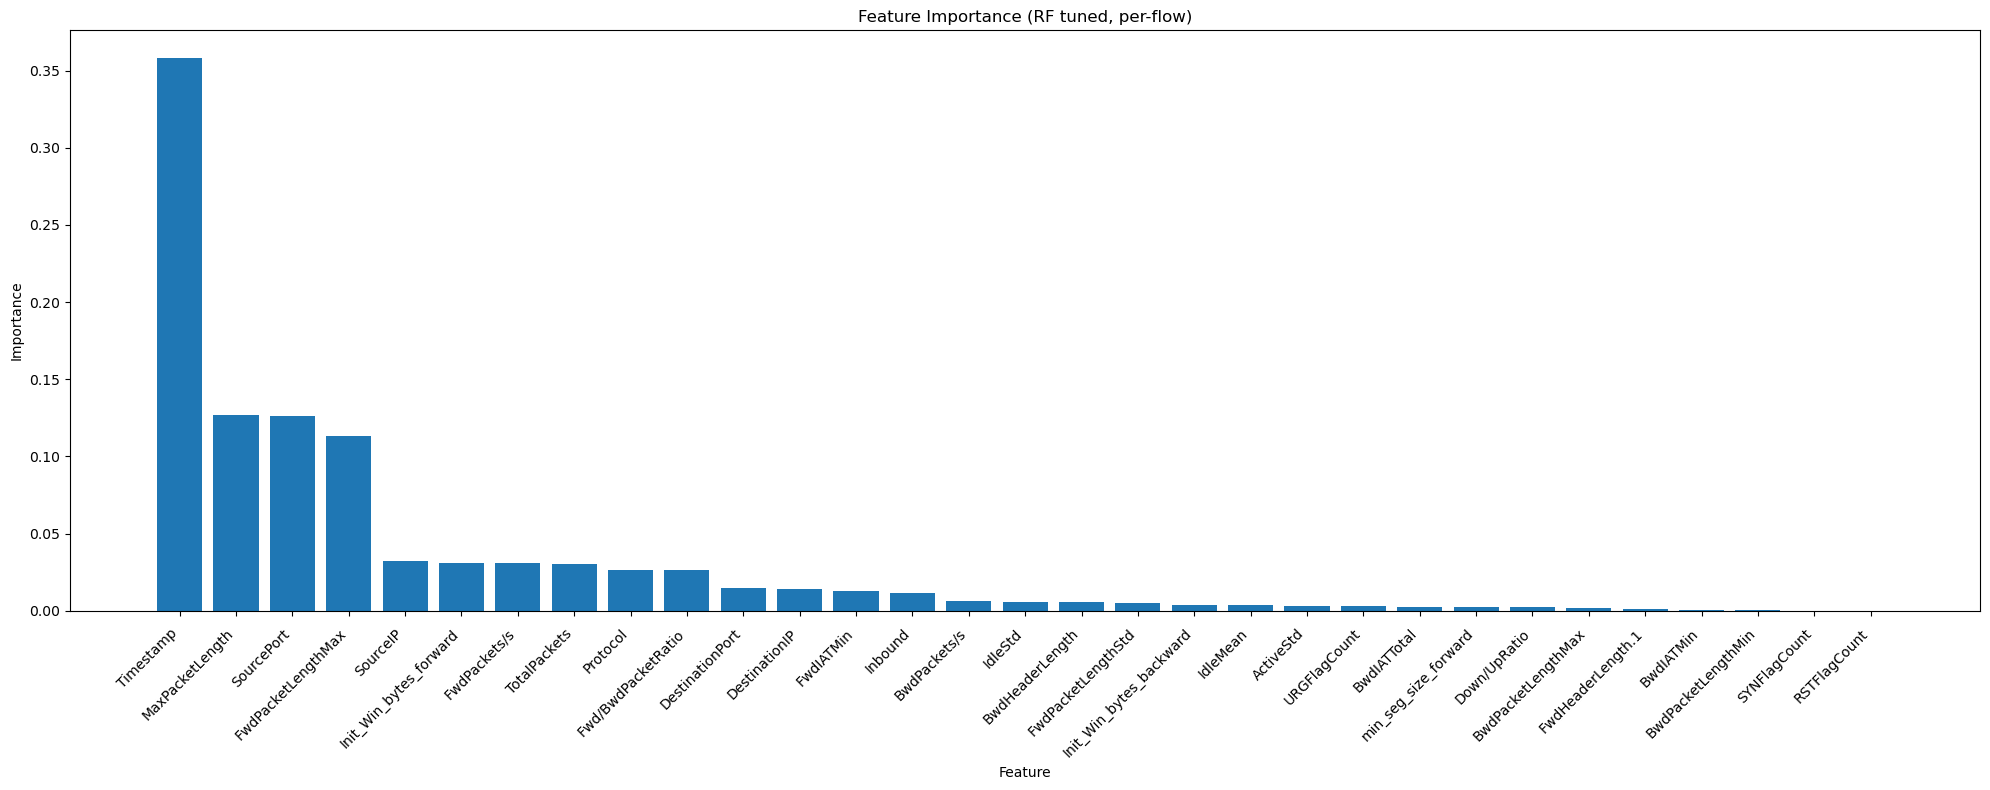

In [ ]:
#Feature importance analysis related to missclassifications

# Feature names from your final feature dataframe
feature_names = X_train_l.columns  # (same as new_df.columns)

# Get feature importances from the trained best RF
feature_importances = rf_final.feature_importances_

# Sort features by importance (descending)
sorted_feature_indices = np.argsort(feature_importances)[::-1]
sorted_feature_names = feature_names[sorted_feature_indices]

plt.figure(figsize=(20, 8))
plt.bar(range(X_train_l.shape[1]), feature_importances[sorted_feature_indices])
plt.xticks(range(X_train_l.shape[1]), sorted_feature_names, rotation=45, ha='right')
plt.tick_params(axis='x', which='major', pad=8)

plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance (RF tuned, per-flow)')
plt.tight_layout()
plt.show()

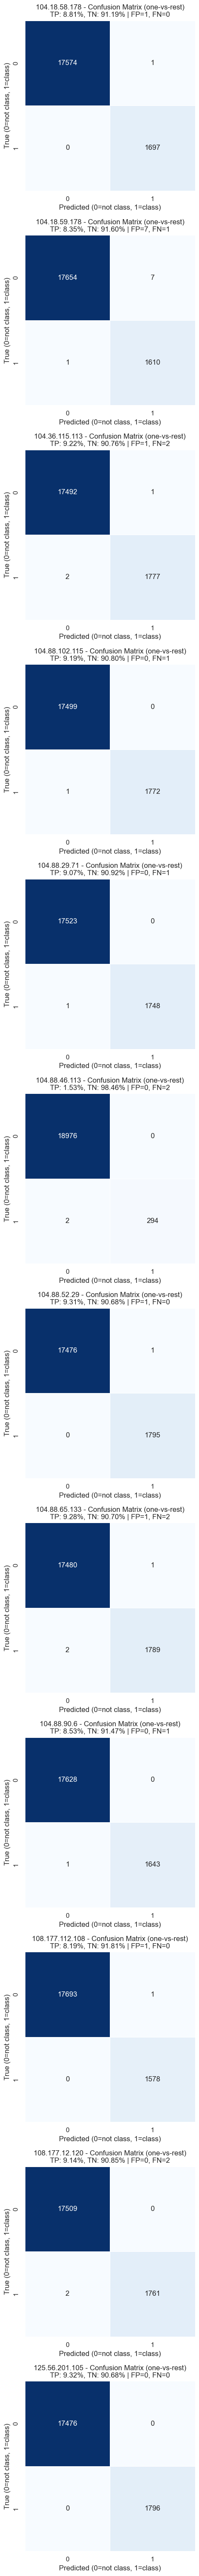

In [91]:
#Confusion matrix of each class for Random Forest model
# Use your per-flow test data + best RF predictions
y_val = np.ravel(y_test_l)
y_val_pred_rf = rf_final.predict(X_test_l)

classes = np.unique(y_val)
sns.set(style="whitegrid")

plt.figure(figsize=(15, 5 * len(classes)))

for i, class_id in enumerate(classes, 1):
    plt.subplot(len(classes), 1, i)

    # One-vs-rest binary vectors for current class
    y_true_binary = (y_val == class_id).astype(int)
    y_pred_binary = (y_val_pred_rf == class_id).astype(int)

    cm = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1])

    tn, fp, fn, tp = cm.ravel()

    total_samples = len(y_val)
    tp_percentage = (tp / total_samples) * 100
    tn_percentage = (tn / total_samples) * 100

    class_name = label_encoder.inverse_transform([class_id])[0]

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True, linewidths=0.5)
    plt.title(
        f'{class_name} - Confusion Matrix (one-vs-rest)\n'
        f'TP: {tp_percentage:.2f}%, TN: {tn_percentage:.2f}% | FP={fp}, FN={fn}',
        fontsize=12
    )
    plt.xlabel("Predicted (0=not class, 1=class)")
    plt.ylabel("True (0=not class, 1=class)")

plt.tight_layout()
plt.show()


In [92]:
# Classification report for Test Data
rf_final.fit(X_train_l, np.ravel(y_train_l))

y_test = np.ravel(y_test_l)
y_pred = rf_final.predict(X_test_l)

print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9994    1.0000    0.9997      1697
           1     0.9957    0.9994    0.9975      1611
           2     0.9994    0.9989    0.9992      1779
           3     1.0000    0.9994    0.9997      1773
           4     1.0000    0.9994    0.9997      1749
           5     1.0000    0.9932    0.9966       296
           6     0.9994    1.0000    0.9997      1795
           7     0.9994    0.9989    0.9992      1791
           8     1.0000    0.9994    0.9997      1644
           9     0.9994    1.0000    0.9997      1578
          10     1.0000    0.9989    0.9994      1763
          11     1.0000    1.0000    1.0000      1796

    accuracy                         0.9994     19272
   macro avg     0.9994    0.9990    0.9992     19272
weighted avg     0.9994    0.9994    0.9994     19272



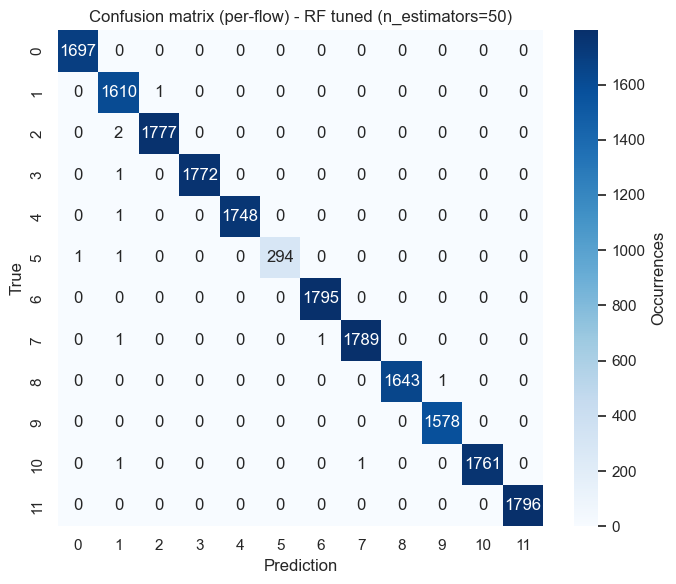

In [93]:
confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(confusion, cmap='Blues', annot=True, cbar_kws={'label': 'Occurrences'}, fmt='d')

plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion matrix (per-flow) - RF tuned (n_estimators=50)')
plt.tight_layout()
plt.show()